In [1]:
import os
import numpy as np
import random
import collections
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image


In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # keep deterministic behavior where possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

CHECKPOINTS_DIR = './checkpoints'
RESULTS_DIR = './results'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 128
EPOCHS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Checkpoints dir: {CHECKPOINTS_DIR}")
print(f"Results dir: {RESULTS_DIR}")



Using device: mps
Checkpoints dir: ./checkpoints
Results dir: ./results


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [5]:
data_iter = iter(train_loader)
batch = next(data_iter)

# A batch usually consists of features (images) and labels
# The structure depends on how your Dataset.__getitem__ is implemented
if isinstance(batch, list) or isinstance(batch, tuple):
    images, labels = batch
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
else:
    # If your dataloader returns a single item
    print(f"Batch shape: {batch.shape}")




Images shape: torch.Size([128, 784])
Labels shape: torch.Size([128])


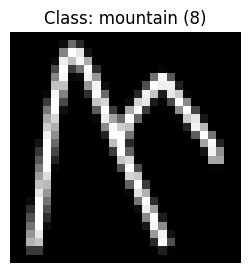

In [6]:
idx = min(60, len(images) - 1)

img = images[idx].numpy().reshape(28, 28)
if img.max() <= 1.0:
    img = img * 255.0
img = img.astype(np.uint8)

class_id = labels[idx].item()
class_names = list(full_train_dataset.classes) if hasattr(full_train_dataset, "classes") else CLASSES
class_name = class_names[class_id]

pil_img = Image.fromarray(img)

plt.figure(figsize=(3, 3))
plt.imshow(pil_img, cmap='gray')
plt.title(f"Class: {class_name} ({class_id})")
plt.axis('off')
plt.show()

In [7]:
# ==========================================
# 4. SHARED TRAINING & DIAGNOSTICS UTILITIES
# ==========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

DATA_MEAN = full_train_dataset.x.mean().item()
DATA_STD = full_train_dataset.x.std().item() + 1e-8
print(f"DATA_MEAN={DATA_MEAN:.6f}, DATA_STD={DATA_STD:.6f}")

def normalize_batch(images):
    return (images.float() - DATA_MEAN) / DATA_STD


class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15, width=256, depth=3, dropout=0.10, act="gelu", use_batchnorm=True):
        super().__init__()
        assert depth >= 2, "depth must be >= 2"

        if act == "relu":
            activation = nn.ReLU()
        elif act == "gelu":
            activation = nn.GELU()
        else:
            raise ValueError("activation must be 'relu' or 'gelu'")

        layers = []
        in_dim = input_size
        for _ in range(depth):
            layers.append(nn.Linear(in_dim, width))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(width))
            layers.append(activation)
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = width

        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


def train_one_epoch(model, train_loader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    grad_sums = collections.defaultdict(float)
    grad_counts = collections.defaultdict(int)

    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)

    for images, labels in train_loader:
        images = normalize_batch(images).to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        for name, param in model.named_parameters():
            if param.grad is not None and param.requires_grad:
                norm_val = param.grad.detach().norm(2).item()
                grad_sums[name] += norm_val
                grad_counts[name] += 1

        optimizer.step()

        if is_onecycle:
            scheduler.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    avg_grad_norms = {k: grad_sums[k] / max(1, grad_counts[k]) for k in grad_sums}
    return total_loss / total_samples, total_correct / total_samples, avg_grad_norms


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = normalize_batch(images).to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def fit_model(
    model,
    model_name,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    scheduler=None,
    epochs=EPOCHS,
    verbose=True,
    save_best_path=None,
    keep_best_in_memory=True,
    best_metric="acc",
):
    history = {
        "model_name": model_name,
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
        "grad_norms": [],
    }

    best_val_acc, best_val_loss, best_epoch = -1.0, float("inf"), -1
    best_state = None

    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)
    is_plateau = isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, grad_norms = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scheduler=scheduler
        )
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        if scheduler is not None:
            if is_plateau:
                scheduler.step(val_acc)
            elif not is_onecycle:
                scheduler.step()

        lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr)
        history["grad_norms"].append(grad_norms)

        improved = (val_acc > best_val_acc) if best_metric == "acc" else (val_loss < best_val_loss)
        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch

            if save_best_path is not None:
                torch.save(model.state_dict(), save_best_path)

            if keep_best_in_memory:
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            print(
                f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
                f"Train: loss {train_loss:.4f}, acc {train_acc:.4f} | "
                f"Val: loss {val_loss:.4f}, acc {val_acc:.4f} | "
                f"LR: {lr:.6f} | Best Val Acc: {best_val_acc:.4f} (ep {best_epoch})"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    history["best_val_acc"] = best_val_acc
    history["best_val_loss"] = best_val_loss
    history["best_epoch"] = best_epoch

    print(f"[{model_name}] Best val acc={best_val_acc:.4f} at epoch {best_epoch}")
    return history


@torch.no_grad()
def get_predictions_and_labels(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = normalize_batch(images).to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)


def plot_training_diagnostics(history, top_k_layers=10):
    epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs_axis, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_axis, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss vs Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_axis, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs_axis, history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy vs Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs_axis, history["lr"], label="Learning Rate")
    axes[2].set_title("Learning Rate vs Epoch")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("LR")
    axes[2].set_yscale("log")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    grad_norms = history.get("grad_norms", [])
    if not grad_norms:
        return

    layer_names = sorted({name for layer_dict in grad_norms for name in layer_dict.keys()})
    means = {}
    for name in layer_names:
        vals = [layer_dict.get(name, np.nan) for layer_dict in grad_norms]
        vals = [value for value in vals if not np.isnan(value)]
        means[name] = float(np.mean(vals)) if vals else 0.0

    top_layers = sorted(means, key=means.get, reverse=True)[:top_k_layers]

    plt.figure(figsize=(12, 6))
    for name in top_layers:
        values = [layer_dict.get(name, np.nan) for layer_dict in grad_norms]
        plt.plot(epochs_axis, values, label=name, alpha=0.85)

    plt.title(f"Gradient Norm Traverse (Top {top_k_layers} layers)")
    plt.xlabel("Epoch")
    plt.ylabel("Avg Grad L2 Norm")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_confusion_and_classwise(model, val_loader, classes, device):
    val_preds, val_labels = get_predictions_and_labels(model, val_loader, device)
    val_acc = (val_preds == val_labels).mean()
    print(f"Validation accuracy: {val_acc:.4f}")

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
    plt.title("Confusion Matrix (Validation Set)")
    plt.show()

    class_totals = cm.sum(axis=1) + 1e-12
    class_acc = cm.diagonal() / class_totals
    print("\nClasswise accuracy (low -> high):")
    for idx in np.argsort(class_acc):
        print(f"{classes[idx]:15s} accuracy: {class_acc[idx]:.3f}")

    return cm, class_acc


@torch.no_grad()
def collect_all_misclassified(model, dataset, device):
    model.eval()
    mis = []

    for idx in range(len(dataset)):
        x, y = dataset[idx]
        if not torch.is_tensor(x):
            x = torch.tensor(x)
        x = x.float().view(1, -1)
        x = ((x - DATA_MEAN) / DATA_STD).to(device)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred = int(probs.argmax())
        conf = float(probs[0, pred])

        if pred != int(y):
            mis.append({
                "idx": idx,
                "true": int(y),
                "pred": pred,
                "conf": conf,
            })

    return mis


def show_misclassified_for_pair(dataset, mis_list, classes, true_class_id, pred_class_id, n=12):
    filtered = [
        item for item in mis_list
        if item["true"] == true_class_id and item["pred"] == pred_class_id
    ]

    if not filtered:
        print(f"No samples where {classes[true_class_id]} -> {classes[pred_class_id]}")
        return

    filtered = sorted(filtered, key=lambda x: x["conf"], reverse=True)[:n]
    cols = 4
    rows = int(np.ceil(len(filtered) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for axis, item in zip(axes, filtered):
        x, _ = dataset[item["idx"]]
        if not torch.is_tensor(x):
            x = torch.tensor(x)
        img = x.float().view(28, 28).cpu()

        axis.imshow(img, cmap="gray")
        axis.set_title(
            f"idx={item['idx']}\ntrue={classes[item['true']]}\npred={classes[item['pred']]}\nconf={item['conf']:.2f}"
        )
        axis.axis("off")

    for axis in axes[len(filtered):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


def show_top_misclassified_pairs(model, dataset, classes, device, top_pairs=2, n_samples_per_pair=12):
    mis = collect_all_misclassified(model, dataset, device)
    if not mis:
        print("No misclassified samples.")
        return mis

    pair_counter = collections.Counter((item["true"], item["pred"]) for item in mis)
    most_common_pairs = pair_counter.most_common(top_pairs)

    print("Top misclassified class pairs:")
    for (true_id, pred_id), count in most_common_pairs:
        print(f"  {classes[true_id]} -> {classes[pred_id]}: {count}")
        show_misclassified_for_pair(
            dataset=dataset,
            mis_list=mis,
            classes=classes,
            true_class_id=true_id,
            pred_class_id=pred_id,
            n=n_samples_per_pair,
        )

    return mis


def run_diagnostics(model, history, val_loader, val_dataset, classes, device, top_k_grad_layers=10):
    plot_training_diagnostics(history, top_k_layers=top_k_grad_layers)
    cm, class_acc = plot_confusion_and_classwise(model, val_loader, classes, device)
    _ = show_top_misclassified_pairs(
        model=model,
        dataset=val_dataset,
        classes=classes,
        device=device,
        top_pairs=5,
        n_samples_per_pair=12,
    )
    return cm, class_acc

DATA_MEAN=0.188342, DATA_STD=0.338611


In [8]:
# Faster misclassification analysis using validation loader batches
@torch.no_grad()
def collect_all_misclassified(model, loader, device):
    model.eval()
    mis = []

    for images, labels in loader:
        images = images.float()
        labels = labels.long()

        logits = model(normalize_batch(images).to(device))
        probs = torch.softmax(logits, dim=1).cpu()
        preds = probs.argmax(dim=1)

        wrong_mask = preds != labels
        if wrong_mask.any():
            wrong_indices = torch.where(wrong_mask)[0]
            for idx in wrong_indices.tolist():
                pred = int(preds[idx].item())
                true = int(labels[idx].item())
                conf = float(probs[idx, pred].item())
                mis.append({
                    "img": images[idx].view(28, 28).cpu(),
                    "true": true,
                    "pred": pred,
                    "conf": conf,
                })

    return mis


def show_misclassified_for_pair(mis_list, classes, true_class_id, pred_class_id, n=12):
    filtered = [
        item for item in mis_list
        if item["true"] == true_class_id and item["pred"] == pred_class_id
    ]

    if not filtered:
        print(f"No samples where {classes[true_class_id]} -> {classes[pred_class_id]}")
        return

    filtered = sorted(filtered, key=lambda x: x["conf"], reverse=True)[:n]
    cols = 4
    rows = int(np.ceil(len(filtered) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for axis, item in zip(axes, filtered):
        axis.imshow(item["img"], cmap="gray")
        axis.set_title(
            f"true={classes[item['true']]}\npred={classes[item['pred']]}\nconf={item['conf']:.2f}"
        )
        axis.axis("off")

    for axis in axes[len(filtered):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


def show_top_misclassified_pairs(model, val_loader, classes, device, top_pairs=5, n_samples_per_pair=12):
    mis = collect_all_misclassified(model, val_loader, device)
    if not mis:
        print("No misclassified samples.")
        return mis

    pair_counter = collections.Counter((item["true"], item["pred"]) for item in mis)
    most_common_pairs = pair_counter.most_common(top_pairs)

    print("Top misclassified class pairs:")
    for (true_id, pred_id), count in most_common_pairs:
        print(f"  {classes[true_id]} -> {classes[pred_id]}: {count}")
        show_misclassified_for_pair(
            mis_list=mis,
            classes=classes,
            true_class_id=true_id,
            pred_class_id=pred_id,
            n=n_samples_per_pair,
        )

    return mis


def run_diagnostics(model, history, val_loader, classes, device, top_k_grad_layers=10):
    plot_training_diagnostics(history, top_k_layers=top_k_grad_layers)
    cm, class_acc = plot_confusion_and_classwise(model, val_loader, classes, device)
    _ = show_top_misclassified_pairs(
        model=model,
        val_loader=val_loader,
        classes=classes,
        device=device,
        top_pairs=5,
        n_samples_per_pair=12,
    )
    return cm, class_acc

In [9]:
# ==========================================
# 4B. AUGMENTATION-AWARE TRAINING OVERRIDE
# ==========================================
import torch.nn.functional as F

def random_shift_single(img, max_shift=2):
    dx = int(torch.randint(-max_shift, max_shift + 1, (1,)).item())
    dy = int(torch.randint(-max_shift, max_shift + 1, (1,)).item())
    pad = max_shift
    padded = F.pad(img.unsqueeze(0), (pad, pad, pad, pad), mode="constant", value=0.0)
    x0 = pad + dx
    y0 = pad + dy
    return padded[:, :, y0:y0 + 28, x0:x0 + 28].squeeze(0)

def augment_batch_for_3layer(images, max_shift=2, shift_prob=0.8, noise_std=0.03, noise_prob=0.25):
    images_2d = images.float().view(-1, 1, 28, 28)
    augmented = images_2d.clone()

    for i in range(augmented.size(0)):
        img = augmented[i]
        if torch.rand(1).item() < shift_prob:
            img = random_shift_single(img, max_shift=max_shift)
        if torch.rand(1).item() < noise_prob:
            img = (img + noise_std * torch.randn_like(img)).clamp(0.0, 1.0)
        augmented[i] = img

    return augmented.view(-1, 784)

def train_one_epoch(model, train_loader, optimizer, criterion, device, scheduler=None, augment_fn=None):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    grad_sums = collections.defaultdict(float)
    grad_counts = collections.defaultdict(int)

    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)

    for images, labels in train_loader:
        images = images.float()
        if augment_fn is not None:
            images = augment_fn(images)
        images = normalize_batch(images).to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        for name, param in model.named_parameters():
            if param.grad is not None and param.requires_grad:
                norm_val = param.grad.detach().norm(2).item()
                grad_sums[name] += norm_val
                grad_counts[name] += 1

        optimizer.step()

        if is_onecycle:
            scheduler.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    avg_grad_norms = {k: grad_sums[k] / max(1, grad_counts[k]) for k in grad_sums}
    return total_loss / total_samples, total_correct / total_samples, avg_grad_norms

def fit_model(
    model,
    model_name,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    scheduler=None,
    epochs=EPOCHS,
    verbose=True,
    save_best_path=None,
    keep_best_in_memory=True,
    best_metric="acc",
    augment_fn=None,
    ):
    history = {
        "model_name": model_name,
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
        "grad_norms": [],
    }

    best_val_acc, best_val_loss, best_epoch = -1.0, float("inf"), -1
    best_state = None

    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)
    is_plateau = isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, grad_norms = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scheduler=scheduler, augment_fn=augment_fn
        )
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        if scheduler is not None:
            if is_plateau:
                scheduler.step(val_acc)
            elif not is_onecycle:
                scheduler.step()

        lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr)
        history["grad_norms"].append(grad_norms)

        improved = (val_acc > best_val_acc) if best_metric == "acc" else (val_loss < best_val_loss)
        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch

            if save_best_path is not None:
                torch.save(model.state_dict(), save_best_path)

            if keep_best_in_memory:
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            print(
                f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
                f"Train: loss {train_loss:.4f}, acc {train_acc:.4f} | "
                f"Val: loss {val_loss:.4f}, acc {val_acc:.4f} | "
                f"LR: {lr:.6f} | Best Val Acc: {best_val_acc:.4f} (ep {best_epoch})"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    history["best_val_acc"] = best_val_acc
    history["best_val_loss"] = best_val_loss
    history["best_epoch"] = best_epoch

    print(f"[{model_name}] Best val acc={best_val_acc:.4f} at epoch {best_epoch}")
    return history

In [10]:
def run_champion_experiment(
    tag,
    width,
    depth,
    act,
    dropout,
    use_batchnorm=True,
    max_lr=5e-3,
    weight_decay=2e-4,
    label_smoothing=0.02,
    epochs=EPOCHS,
    use_augmentation=None,
    run_live_diagnostics=False,
    top_k_grad_layers=10,
    ):
    print("\n" + "=" * 80)
    print(f"Running {tag}")
    print("=" * 80)

    if use_augmentation is None:
        use_augmentation = True
    augment_fn = augment_batch_for_3layer if use_augmentation else None
    print(f"Augmentation enabled: {use_augmentation}")

    model = ChampionMLP(
        num_classes=NUM_CLASSES,
        width=width,
        depth=depth,
        dropout=dropout,
        act=act,
        use_batchnorm=use_batchnorm,
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params}")

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=max_lr / 8.0,
        weight_decay=weight_decay,
        betas=(0.9, 0.99),
    )
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.2,
        anneal_strategy="cos",
        div_factor=8,
        final_div_factor=1000,
    )

    checkpoint_dir = globals().get("CHECKPOINTS_DIR", "./checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(checkpoint_dir, f"best_{tag.lower().replace(' ', '_')}.pth")
    history = fit_model(
        model=model,
        model_name=tag,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        device=DEVICE,
        epochs=epochs,
        verbose=True,
        save_best_path=ckpt_path,
        augment_fn=augment_fn,
    )

    print(f"Saved best checkpoint: {ckpt_path}")

    val_preds, val_labels = get_predictions_and_labels(model, val_loader, DEVICE)
    cm = confusion_matrix(val_labels, val_preds)
    class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-12)

    if run_live_diagnostics:
        _ = run_diagnostics(
            model=model,
            history=history,
            val_loader=val_loader,
            classes=CLASSES,
            device=DEVICE,
            top_k_grad_layers=top_k_grad_layers,
        )

    return {
        "model": model,
        "history": history,
        "cm": cm,
        "class_acc": class_acc,
        "checkpoint": ckpt_path,
        "params": total_params,
        "activation": act.upper(),
        "hidden_layers": depth,
        "weight_decay": weight_decay,
        "scheduler": "OneCycleLR",
        "use_augmentation": use_augmentation,
        "val_preds": val_preds,
        "val_labels": val_labels,
    }


## 1) ChampionMLP with ReLU 3 layers


Running ChampionMLP_RELU_3L
Augmentation enabled: True
Trainable parameters: 937999
[ChampionMLP_RELU_3L] Epoch 01/40 | Train: loss 1.3591, acc 0.5771 | Val: loss 0.9838, acc 0.7077 | LR: 0.000950 | Best Val Acc: 0.7077 (ep 1)
[ChampionMLP_RELU_3L] Epoch 02/40 | Train: loss 1.0967, acc 0.6622 | Val: loss 0.9359, acc 0.7209 | LR: 0.001519 | Best Val Acc: 0.7209 (ep 2)
[ChampionMLP_RELU_3L] Epoch 03/40 | Train: loss 1.0412, acc 0.6842 | Val: loss 0.9137, acc 0.7357 | LR: 0.002371 | Best Val Acc: 0.7357 (ep 3)
[ChampionMLP_RELU_3L] Epoch 04/40 | Train: loss 1.0036, acc 0.6968 | Val: loss 0.8958, acc 0.7416 | LR: 0.003376 | Best Val Acc: 0.7416 (ep 4)
[ChampionMLP_RELU_3L] Epoch 05/40 | Train: loss 0.9755, acc 0.7057 | Val: loss 0.8651, acc 0.7468 | LR: 0.004381 | Best Val Acc: 0.7468 (ep 5)
[ChampionMLP_RELU_3L] Epoch 06/40 | Train: loss 0.9373, acc 0.7208 | Val: loss 0.8160, acc 0.7661 | LR: 0.005233 | Best Val Acc: 0.7661 (ep 6)
[ChampionMLP_RELU_3L] Epoch 07/40 | Train: loss 0.9028, a

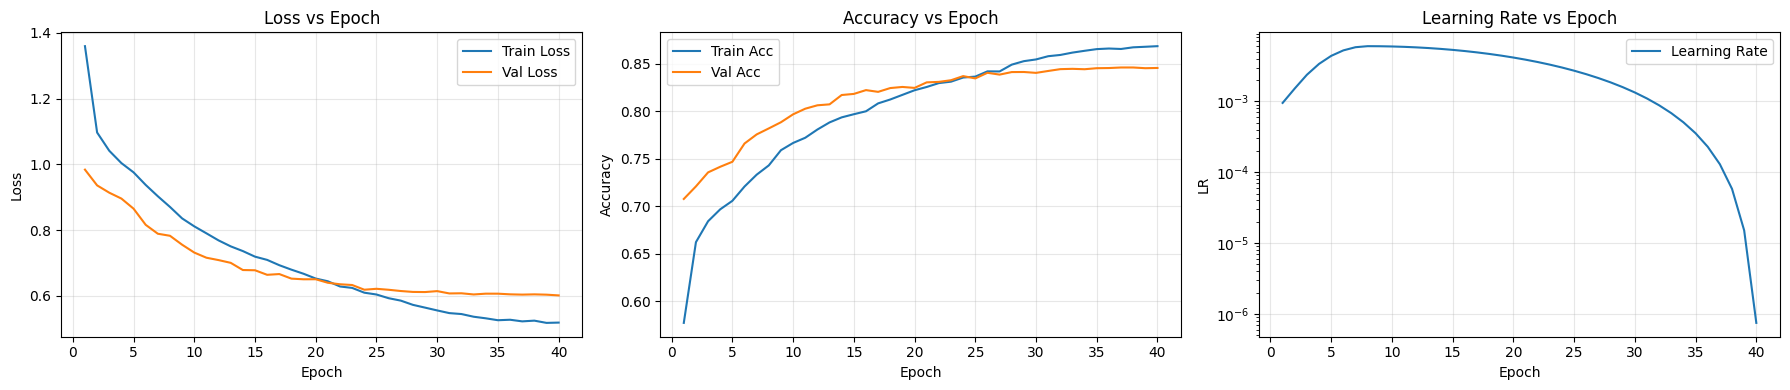

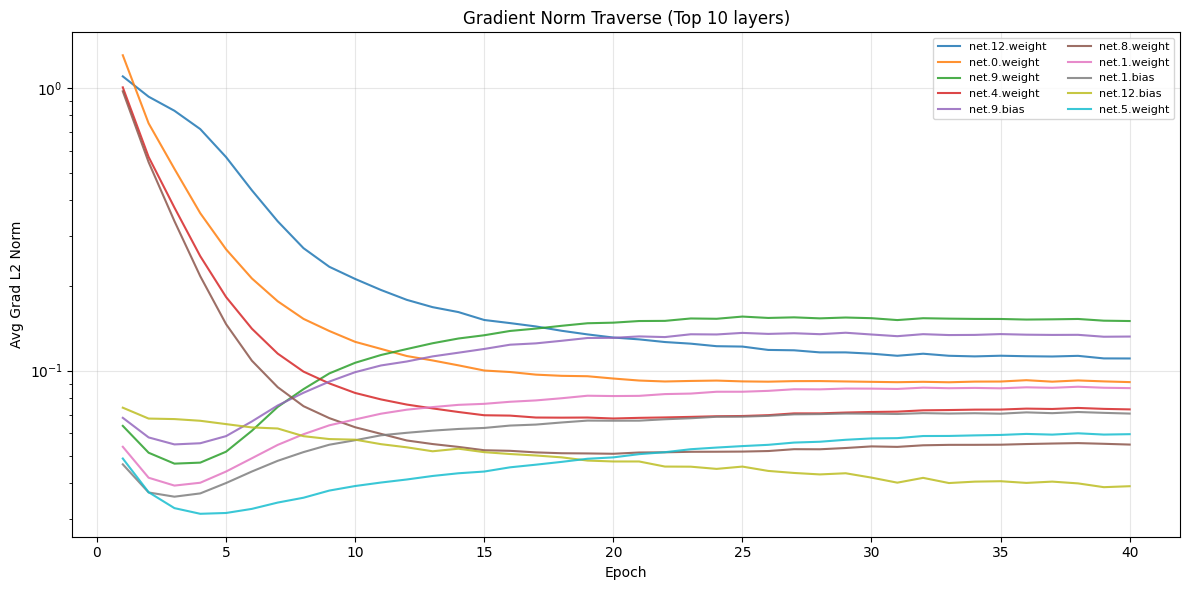

Validation accuracy: 0.8462


<Figure size 1200x1000 with 0 Axes>

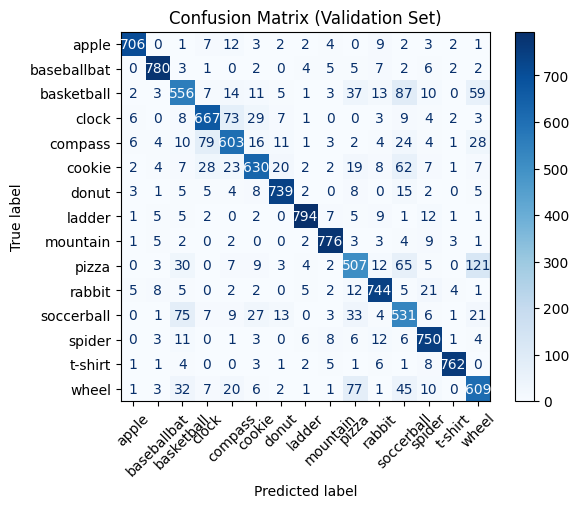


Classwise accuracy (low -> high):
pizza           accuracy: 0.660
basketball      accuracy: 0.688
soccerball      accuracy: 0.726
wheel           accuracy: 0.747
compass         accuracy: 0.758
cookie          accuracy: 0.766
clock           accuracy: 0.821
rabbit          accuracy: 0.912
spider          accuracy: 0.925
donut           accuracy: 0.927
apple           accuracy: 0.936
ladder          accuracy: 0.940
baseballbat     accuracy: 0.952
mountain        accuracy: 0.957
t-shirt         accuracy: 0.958
Top misclassified class pairs:
  pizza -> wheel: 121


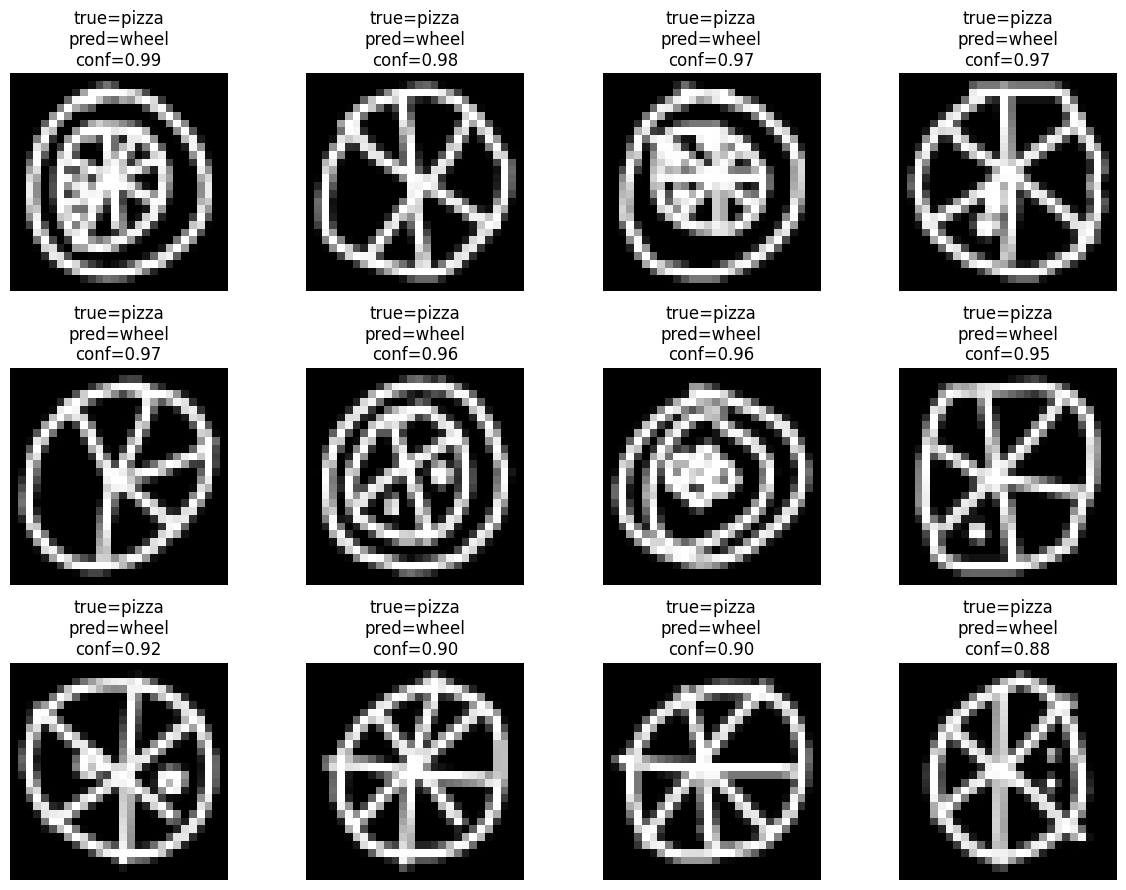

  basketball -> soccerball: 87


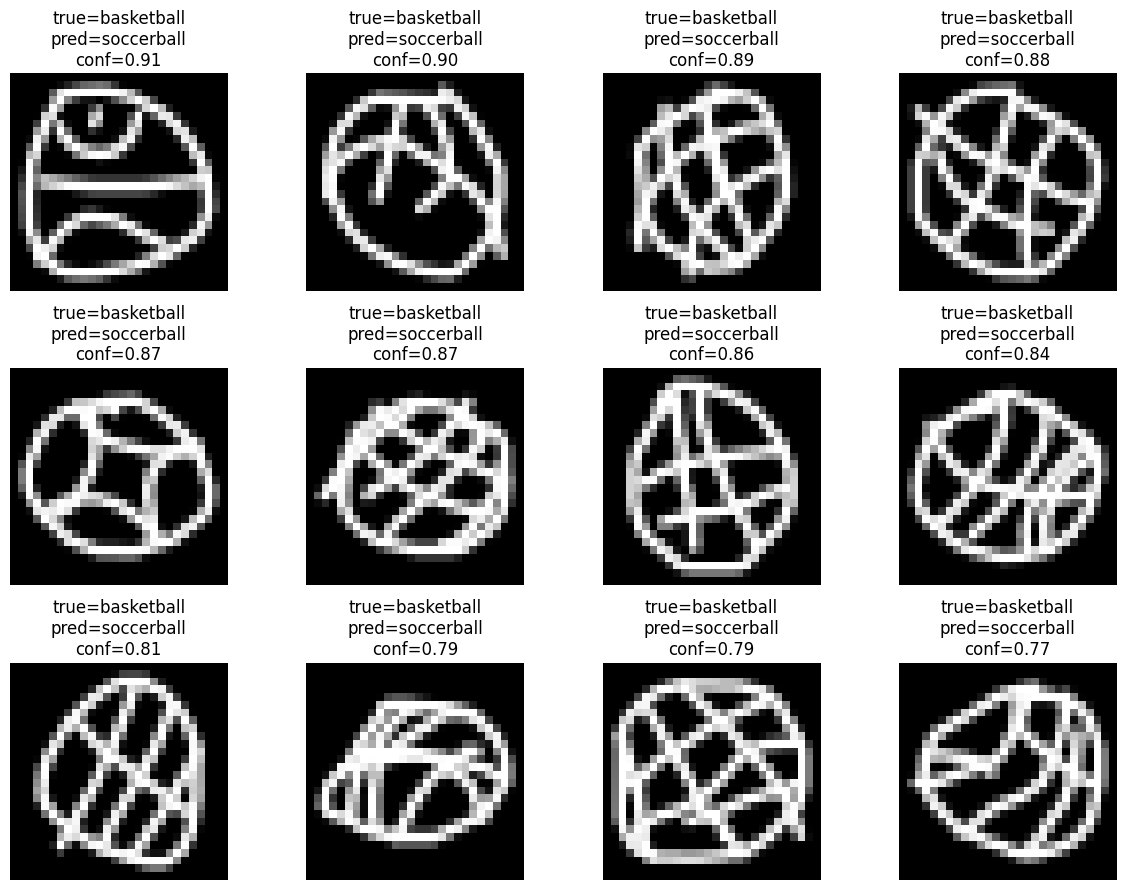

  compass -> clock: 79


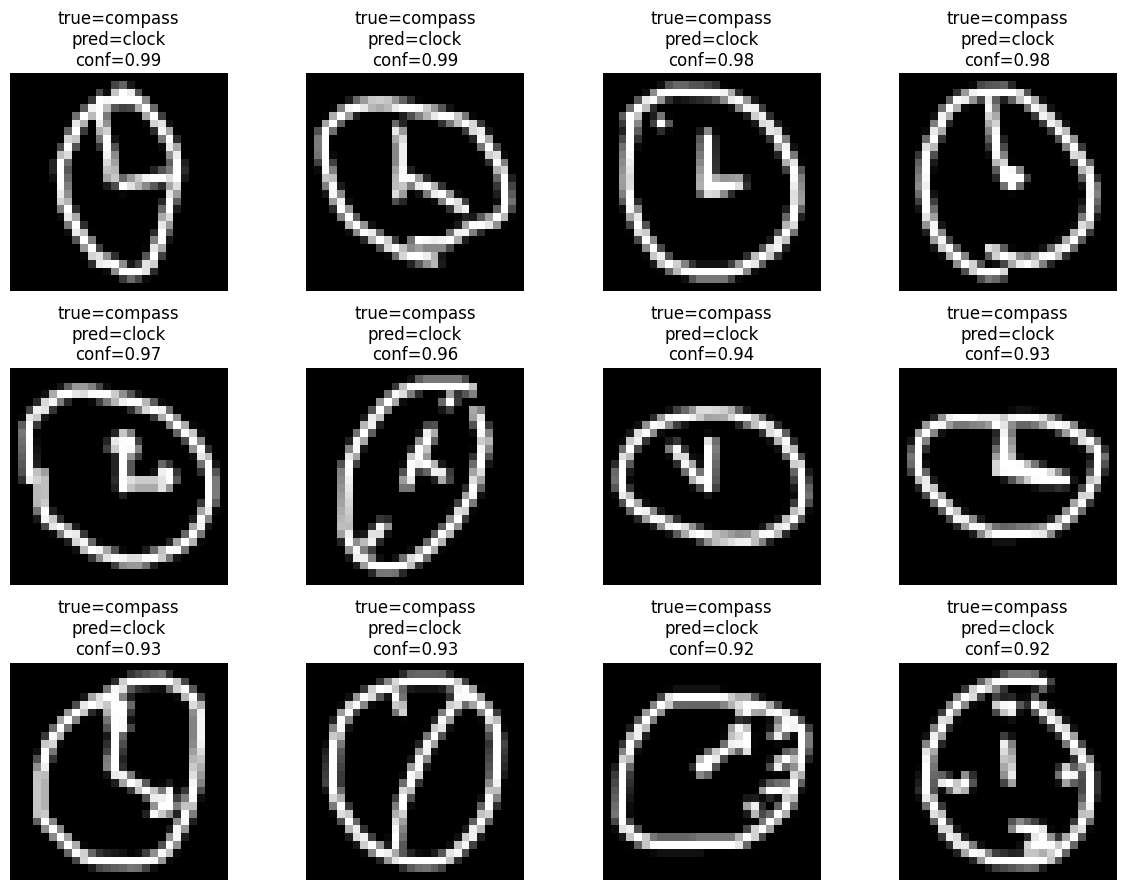

  wheel -> pizza: 77


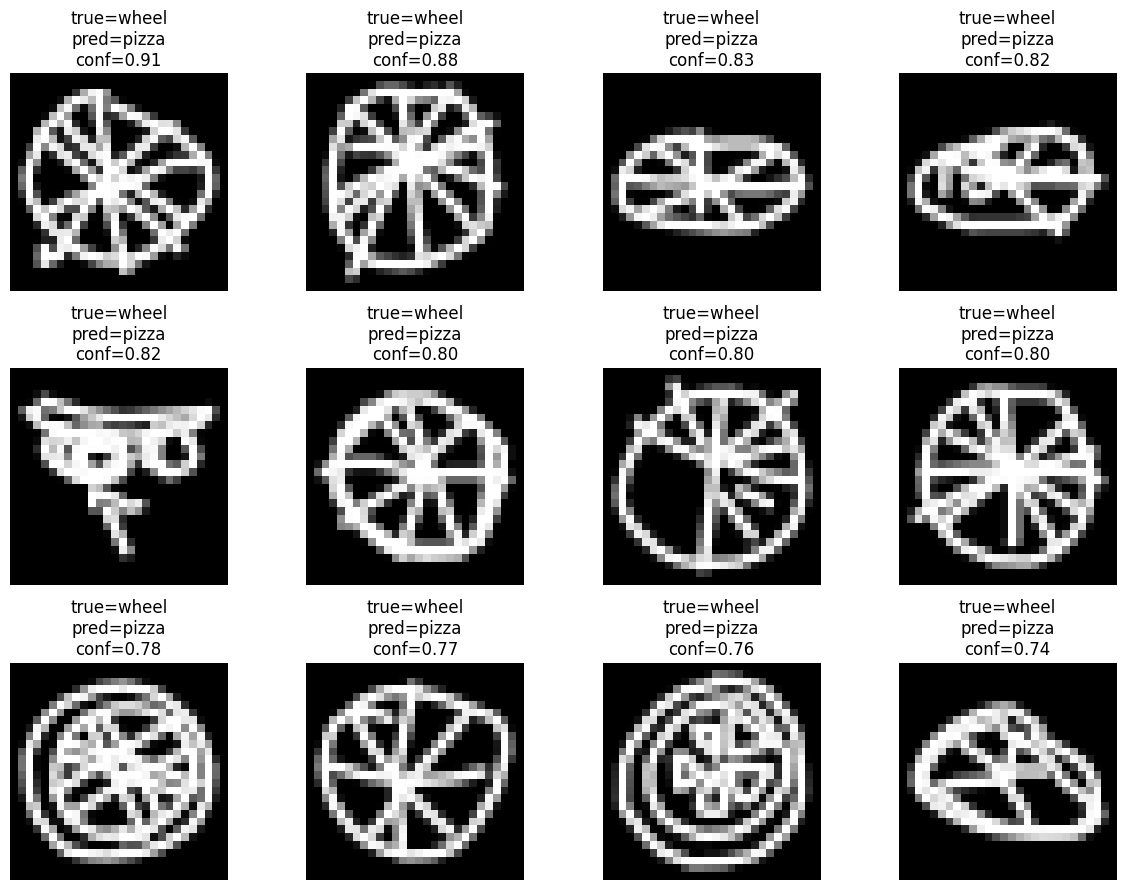

  soccerball -> basketball: 75


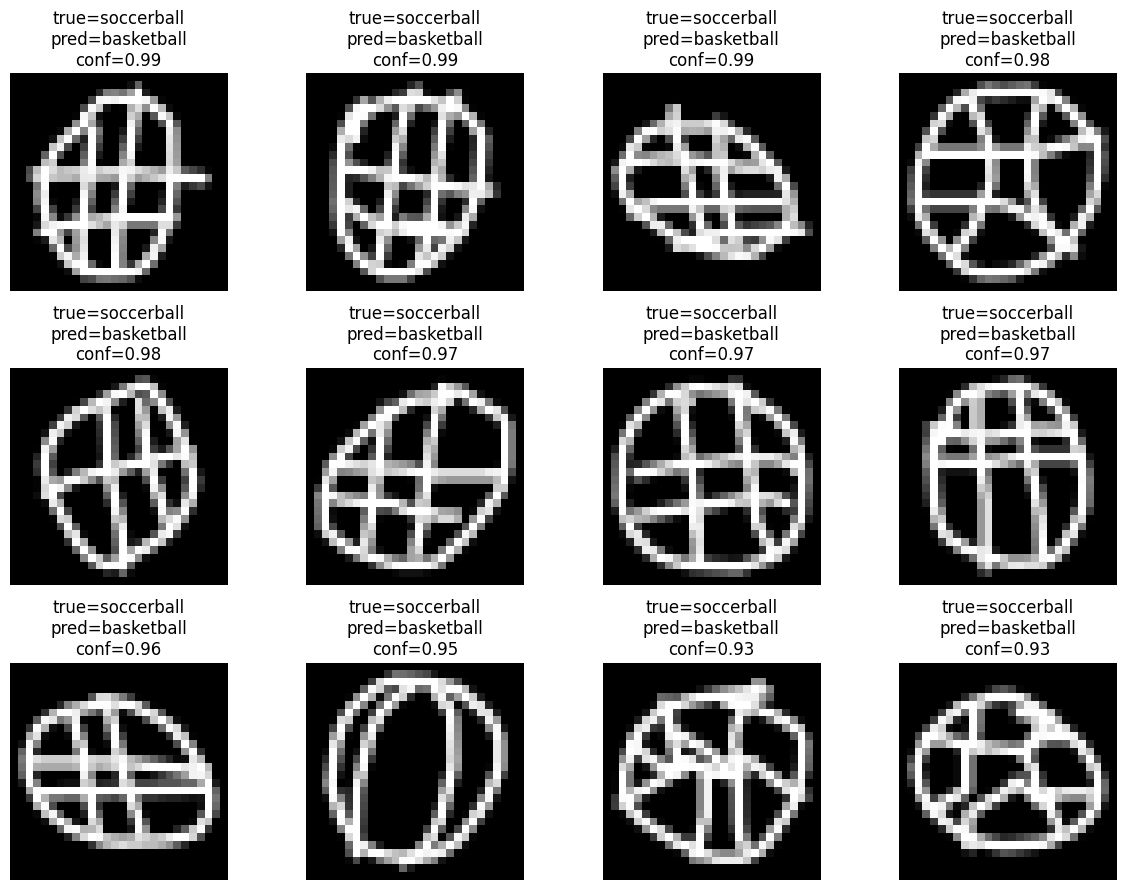

In [11]:
relu3_results = run_champion_experiment(
    tag="ChampionMLP_RELU_3L",
    width=512,
    depth=3,
    act="relu",
    dropout=0.10,
    use_batchnorm=True,
    max_lr=6e-3,
    weight_decay=1e-4,
    label_smoothing=0.02,
    epochs=EPOCHS,
    use_augmentation=True,
    run_live_diagnostics=True,
    top_k_grad_layers=10,
 )

## 2) ChampionMLP with GELU 2 layers


Running ChampionMLP_GELU_2L
Augmentation enabled: True
Trainable parameters: 674319
[ChampionMLP_GELU_2L] Epoch 01/40 | Train: loss 1.3302, acc 0.5895 | Val: loss 0.9903, acc 0.7100 | LR: 0.000950 | Best Val Acc: 0.7100 (ep 1)
[ChampionMLP_GELU_2L] Epoch 02/40 | Train: loss 1.0665, acc 0.6782 | Val: loss 0.9179, acc 0.7296 | LR: 0.001519 | Best Val Acc: 0.7296 (ep 2)
[ChampionMLP_GELU_2L] Epoch 03/40 | Train: loss 1.0042, acc 0.6996 | Val: loss 0.8833, acc 0.7458 | LR: 0.002371 | Best Val Acc: 0.7458 (ep 3)
[ChampionMLP_GELU_2L] Epoch 04/40 | Train: loss 0.9731, acc 0.7101 | Val: loss 0.8570, acc 0.7570 | LR: 0.003376 | Best Val Acc: 0.7570 (ep 4)
[ChampionMLP_GELU_2L] Epoch 05/40 | Train: loss 0.9290, acc 0.7260 | Val: loss 0.8256, acc 0.7680 | LR: 0.004381 | Best Val Acc: 0.7680 (ep 5)
[ChampionMLP_GELU_2L] Epoch 06/40 | Train: loss 0.8984, acc 0.7383 | Val: loss 0.8065, acc 0.7732 | LR: 0.005233 | Best Val Acc: 0.7732 (ep 6)
[ChampionMLP_GELU_2L] Epoch 07/40 | Train: loss 0.8618, a

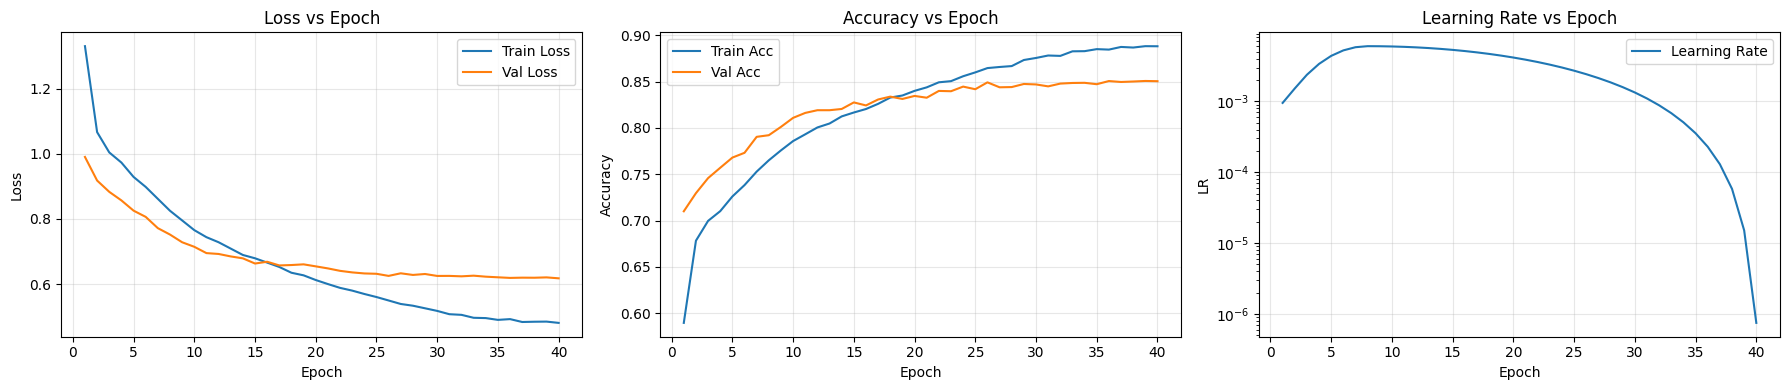

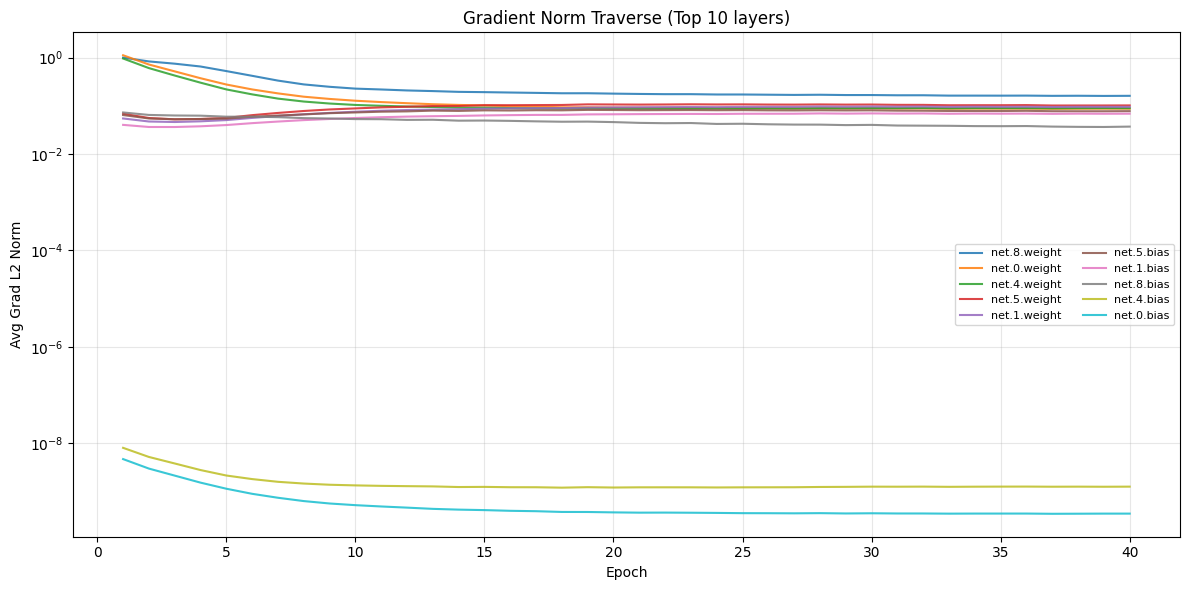

Validation accuracy: 0.8508


<Figure size 1200x1000 with 0 Axes>

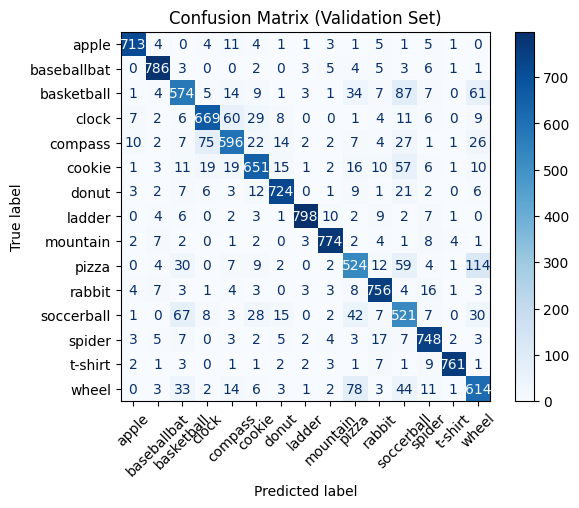


Classwise accuracy (low -> high):
pizza           accuracy: 0.682
basketball      accuracy: 0.710
soccerball      accuracy: 0.713
compass         accuracy: 0.749
wheel           accuracy: 0.753
cookie          accuracy: 0.792
clock           accuracy: 0.824
donut           accuracy: 0.908
spider          accuracy: 0.922
rabbit          accuracy: 0.926
ladder          accuracy: 0.944
apple           accuracy: 0.946
mountain        accuracy: 0.954
t-shirt         accuracy: 0.957
baseballbat     accuracy: 0.960
Top misclassified class pairs:
  pizza -> wheel: 114


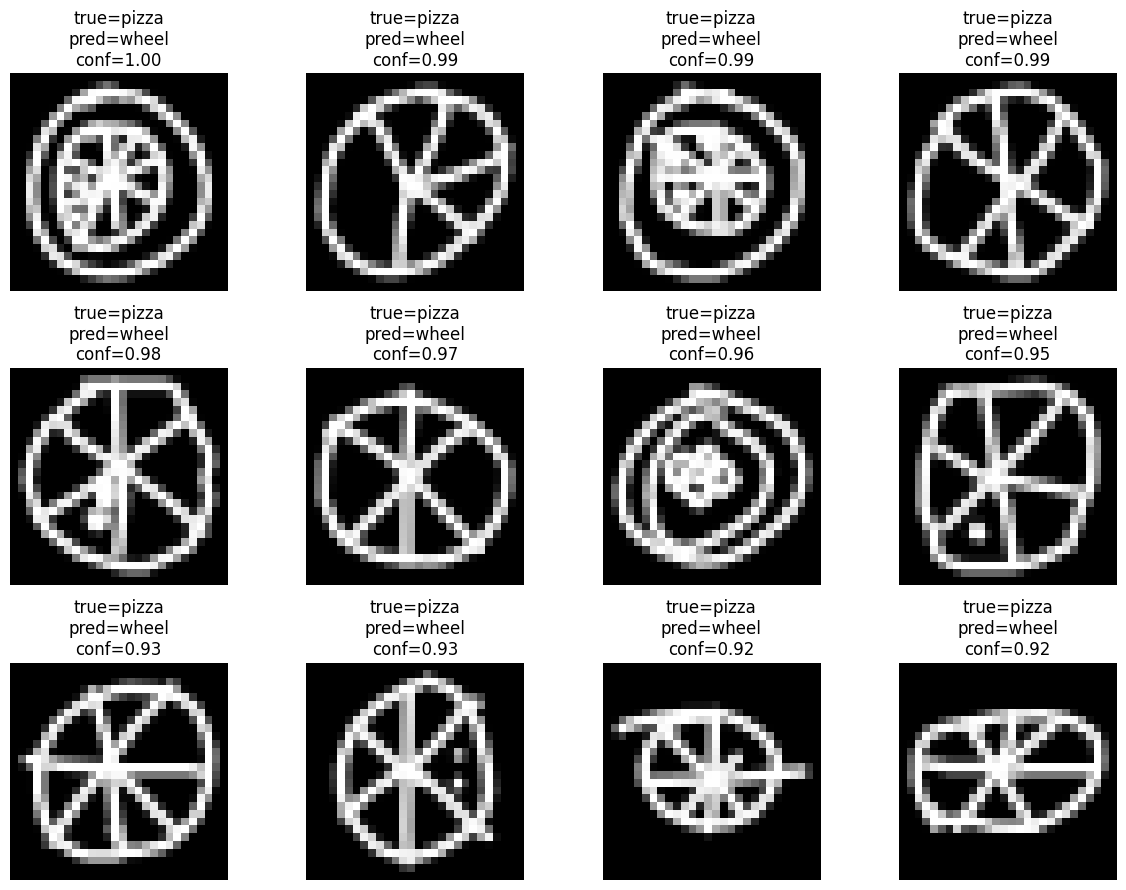

  basketball -> soccerball: 87


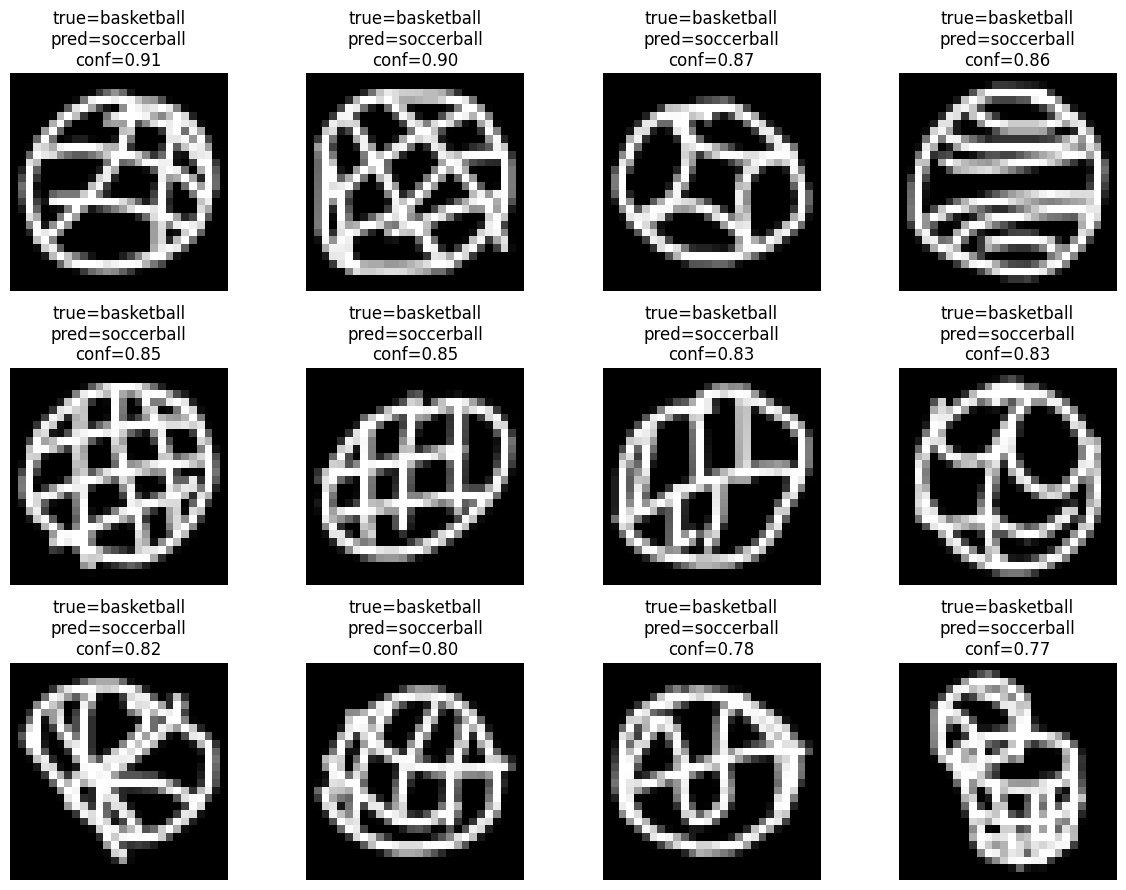

  wheel -> pizza: 78


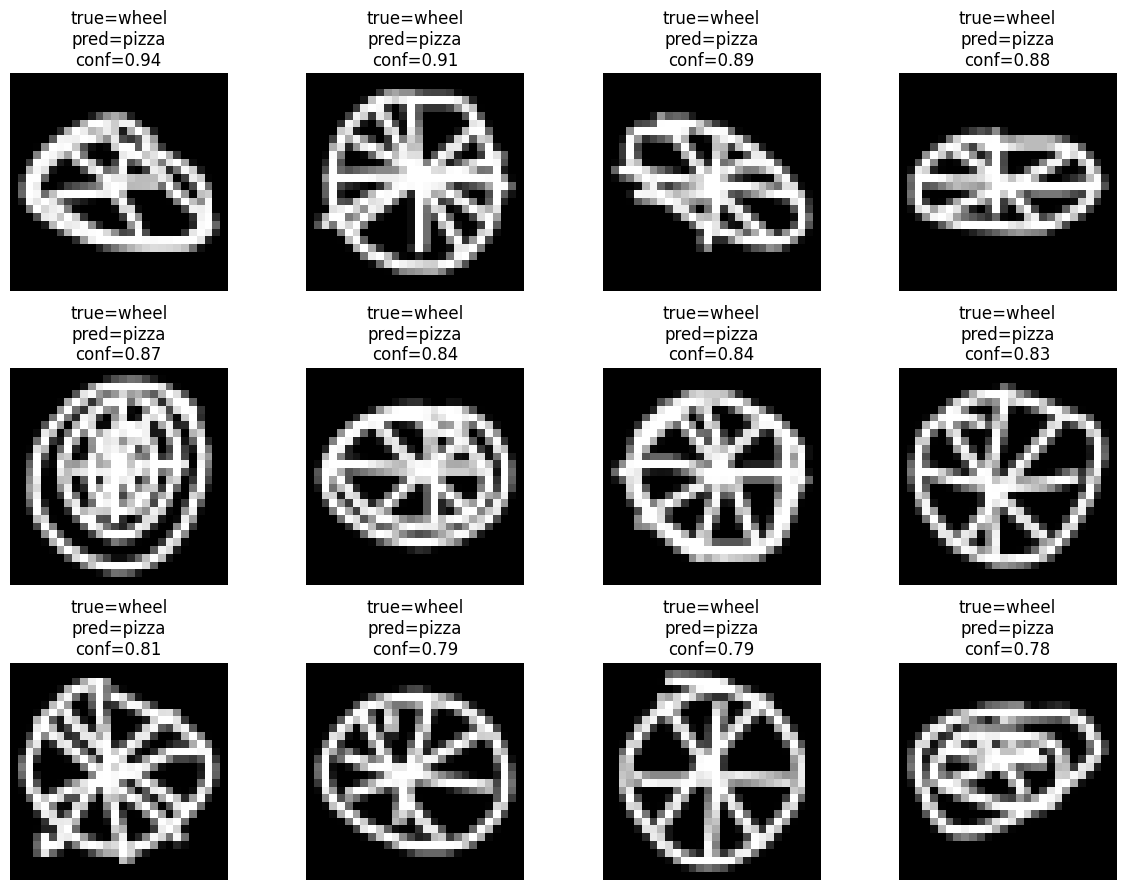

  compass -> clock: 75


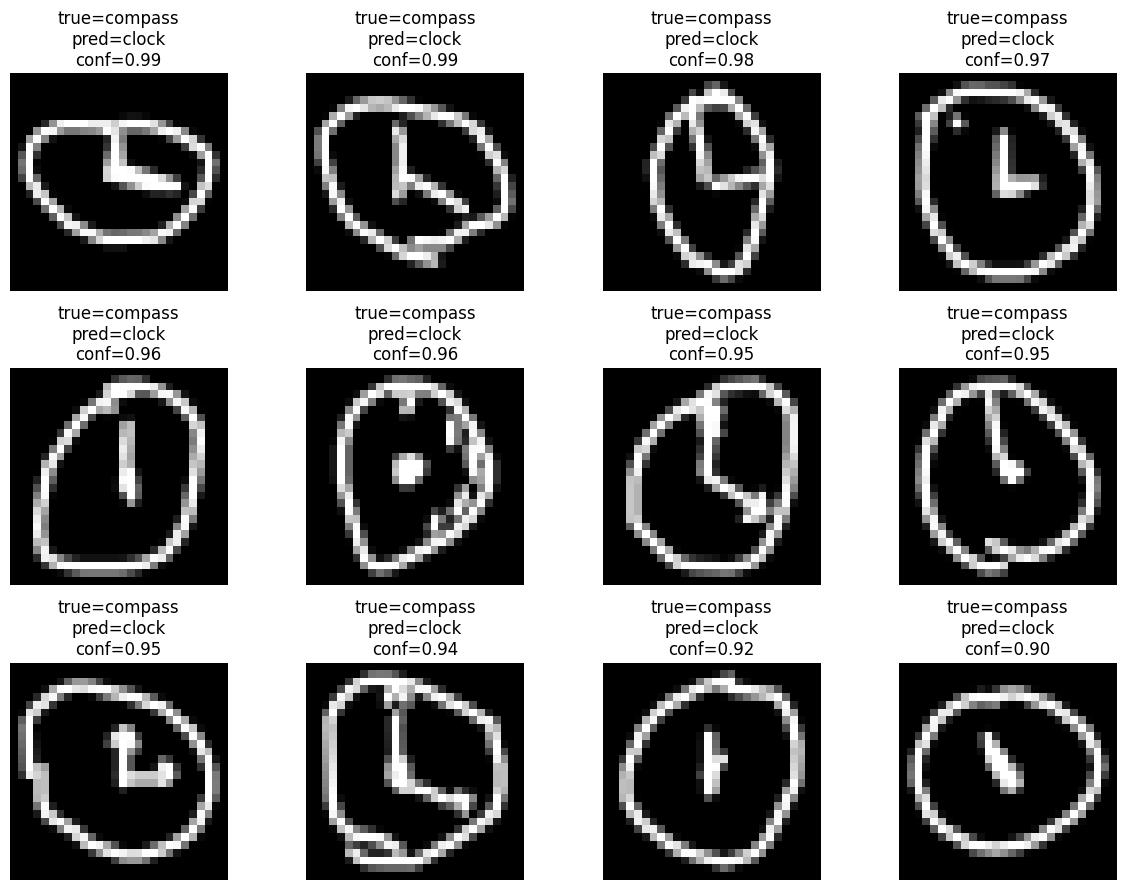

  soccerball -> basketball: 67


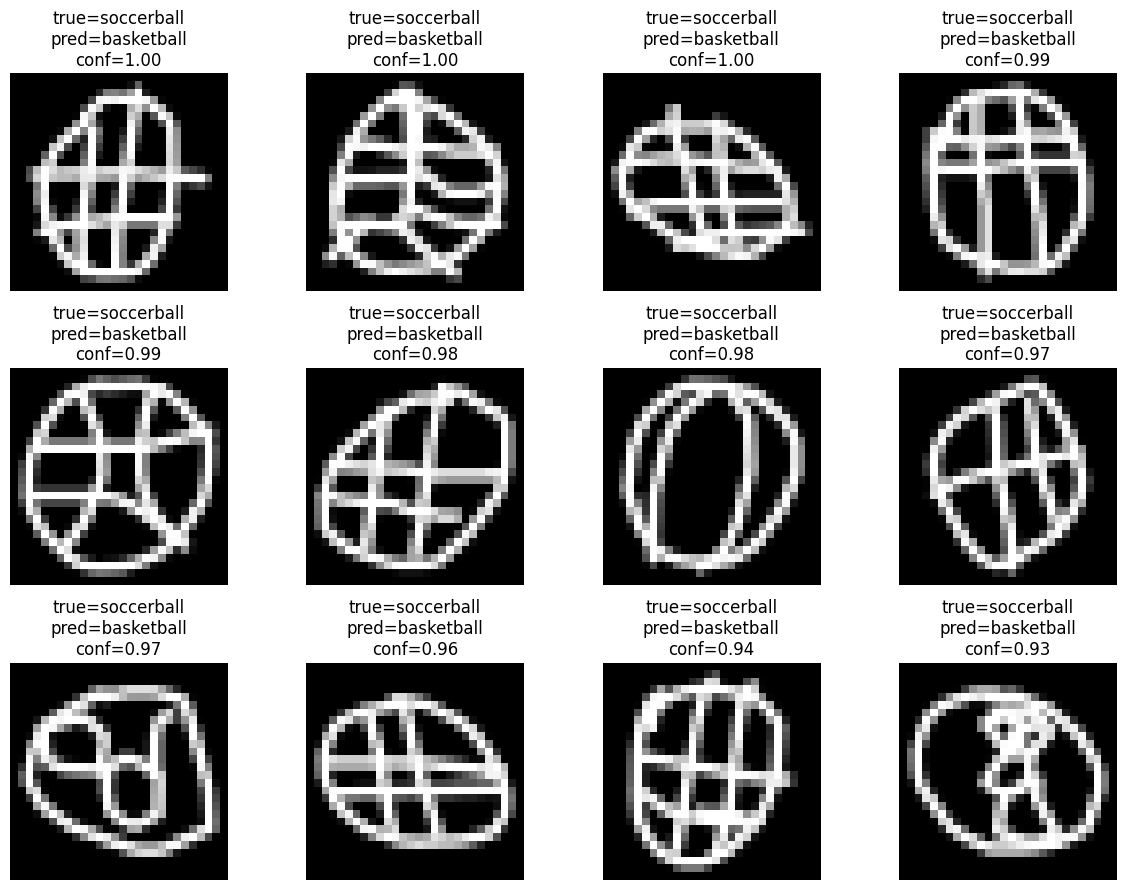

In [12]:
gelu2_results = run_champion_experiment(
    tag="ChampionMLP_GELU_2L",
    width=512,
    depth=2,
    act="gelu",
    dropout=0.10,
    use_batchnorm=True,
    max_lr=6e-3,
    weight_decay=1e-4,
    label_smoothing=0.02,
    epochs=EPOCHS,
    use_augmentation=True,
    run_live_diagnostics=True,
    top_k_grad_layers=10,
 )

## 3) ChampionMLP with GELU 3 layers


Running ChampionMLP_GELU_3L
Augmentation enabled: True
Trainable parameters: 937999
[ChampionMLP_GELU_3L] Epoch 01/40 | Train: loss 1.3098, acc 0.5928 | Val: loss 0.9651, acc 0.7128 | LR: 0.000950 | Best Val Acc: 0.7128 (ep 1)
[ChampionMLP_GELU_3L] Epoch 02/40 | Train: loss 1.0622, acc 0.6758 | Val: loss 0.9276, acc 0.7256 | LR: 0.001519 | Best Val Acc: 0.7256 (ep 2)
[ChampionMLP_GELU_3L] Epoch 03/40 | Train: loss 1.0089, acc 0.6938 | Val: loss 0.8981, acc 0.7400 | LR: 0.002371 | Best Val Acc: 0.7400 (ep 3)
[ChampionMLP_GELU_3L] Epoch 04/40 | Train: loss 0.9708, acc 0.7083 | Val: loss 0.8589, acc 0.7525 | LR: 0.003376 | Best Val Acc: 0.7525 (ep 4)
[ChampionMLP_GELU_3L] Epoch 05/40 | Train: loss 0.9316, acc 0.7255 | Val: loss 0.8439, acc 0.7605 | LR: 0.004381 | Best Val Acc: 0.7605 (ep 5)
[ChampionMLP_GELU_3L] Epoch 06/40 | Train: loss 0.8967, acc 0.7371 | Val: loss 0.7902, acc 0.7773 | LR: 0.005233 | Best Val Acc: 0.7773 (ep 6)
[ChampionMLP_GELU_3L] Epoch 07/40 | Train: loss 0.8583, a

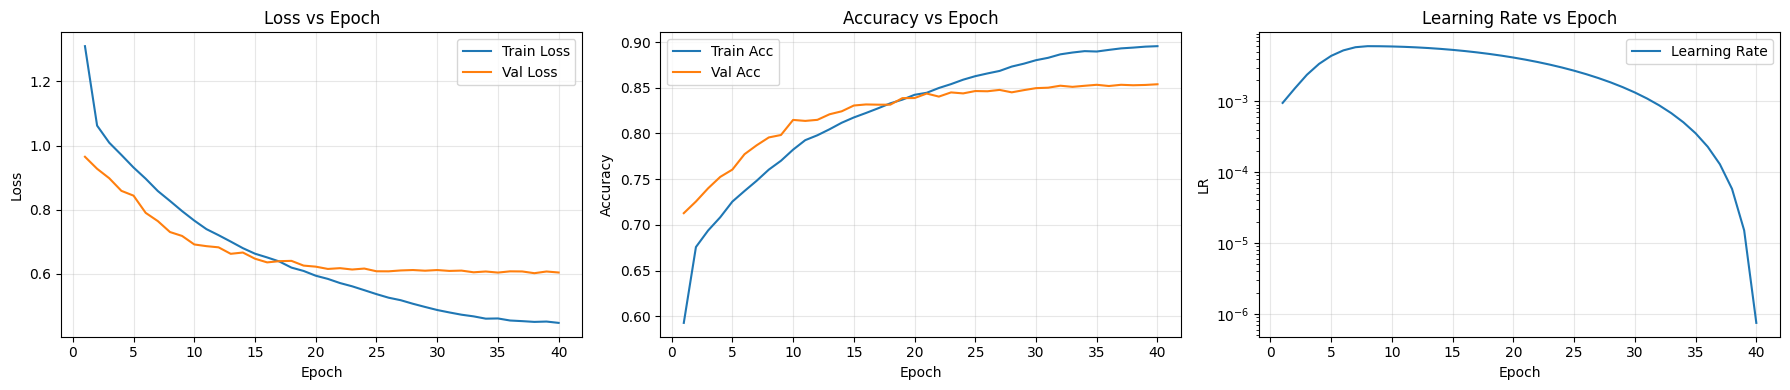

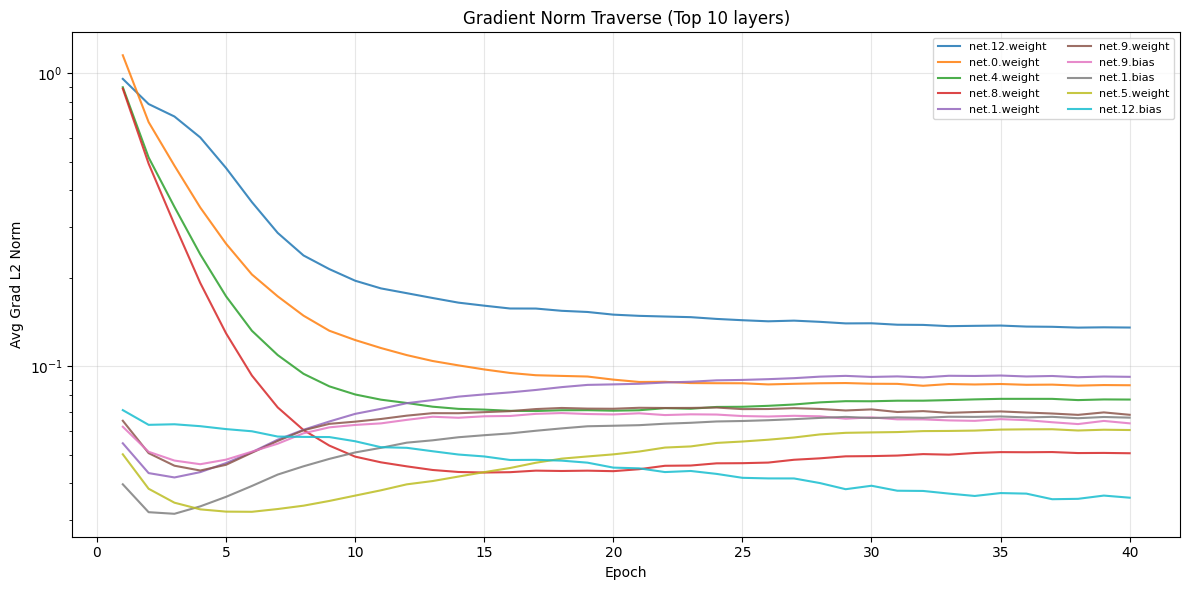

Validation accuracy: 0.8538


<Figure size 1200x1000 with 0 Axes>

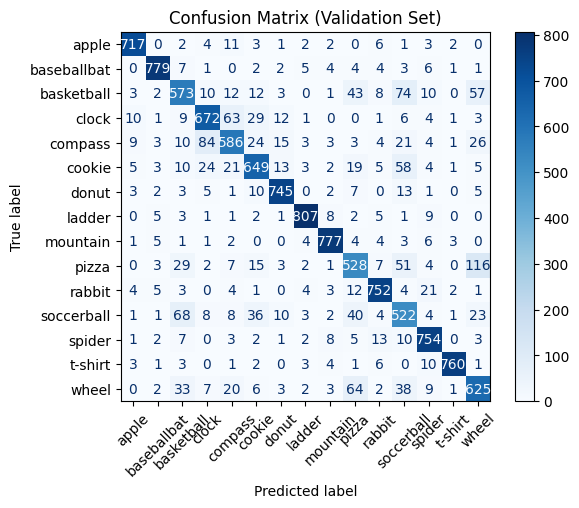


Classwise accuracy (low -> high):
pizza           accuracy: 0.687
basketball      accuracy: 0.709
soccerball      accuracy: 0.714
compass         accuracy: 0.736
wheel           accuracy: 0.767
cookie          accuracy: 0.790
clock           accuracy: 0.828
rabbit          accuracy: 0.922
spider          accuracy: 0.930
donut           accuracy: 0.935
apple           accuracy: 0.951
baseballbat     accuracy: 0.951
ladder          accuracy: 0.955
t-shirt         accuracy: 0.956
mountain        accuracy: 0.958
Top misclassified class pairs:
  pizza -> wheel: 116


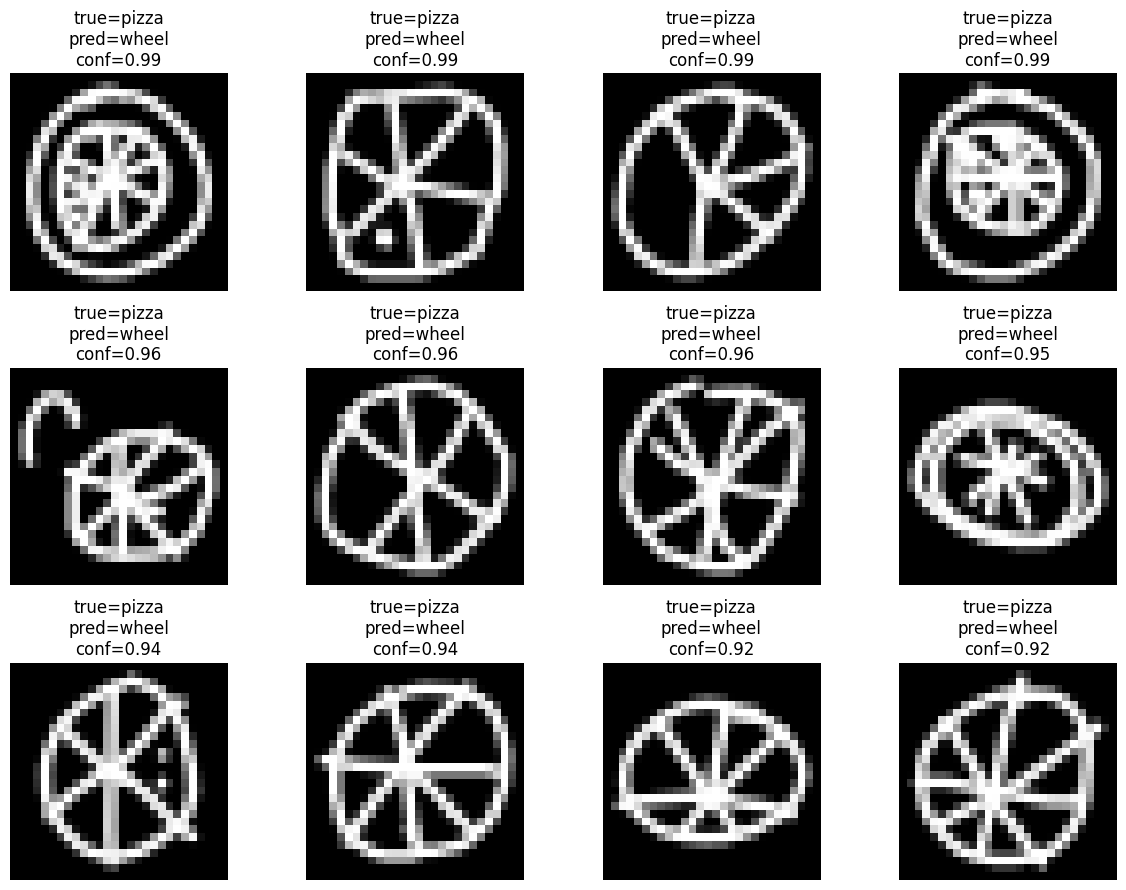

  compass -> clock: 84


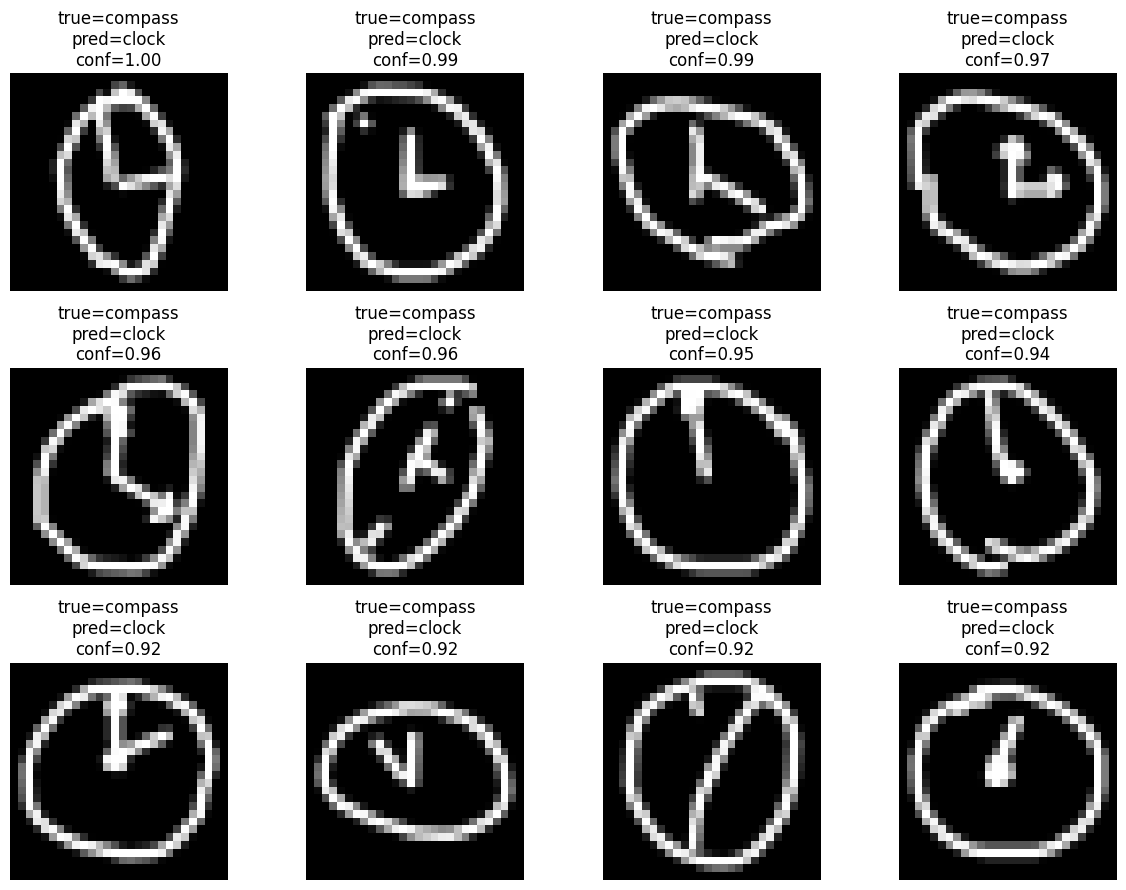

  basketball -> soccerball: 74


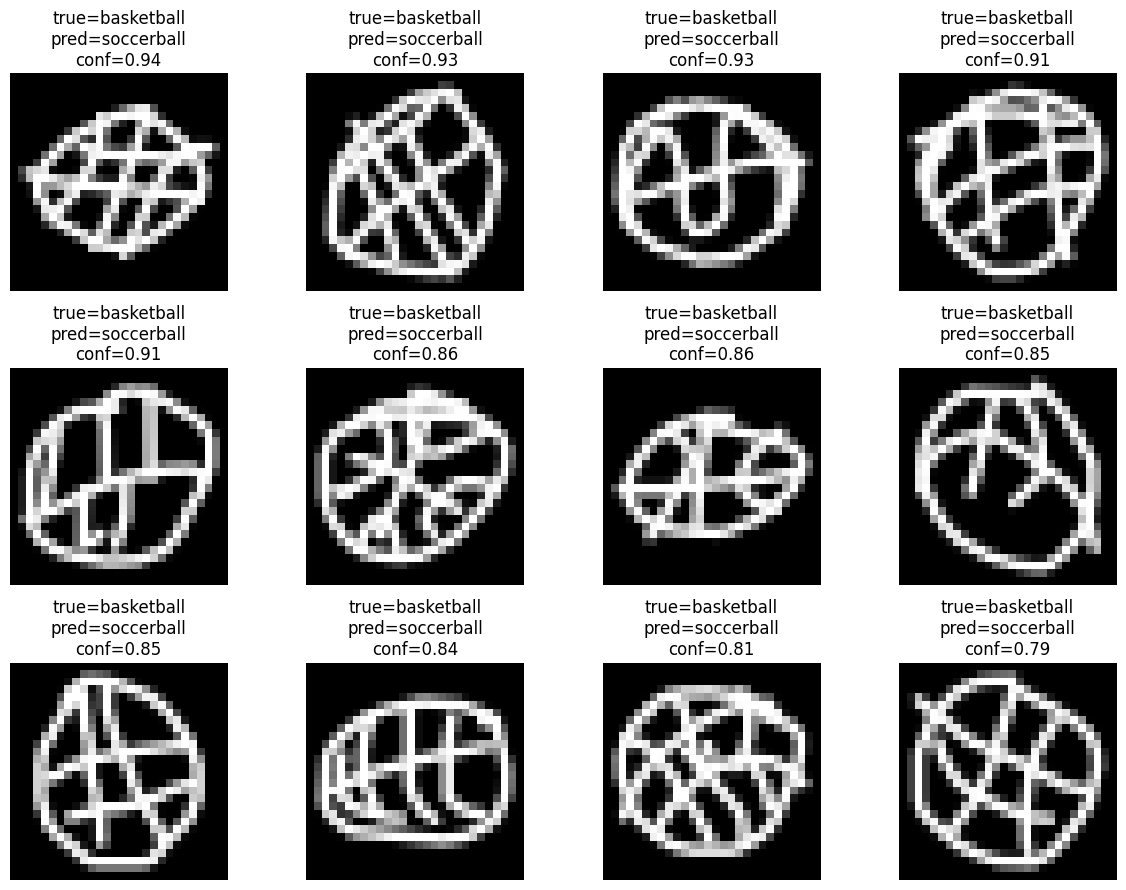

  soccerball -> basketball: 68


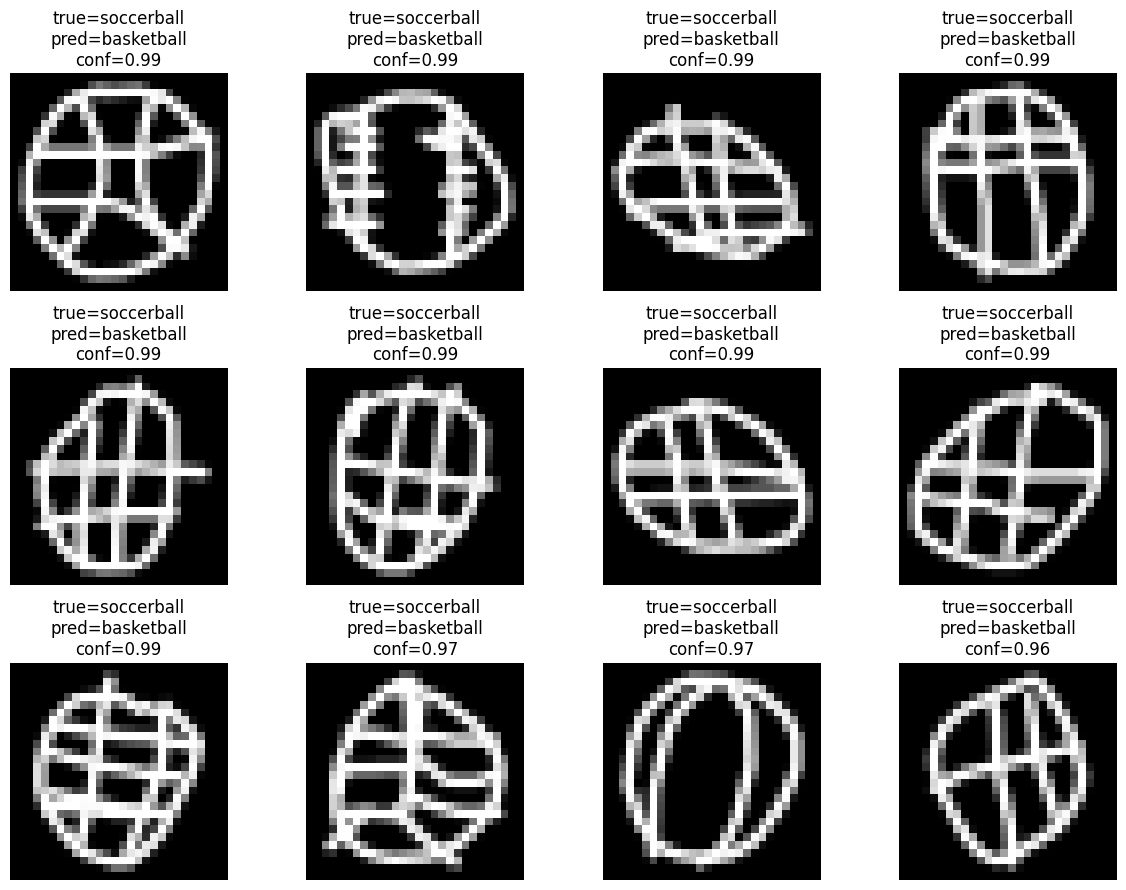

  wheel -> pizza: 64


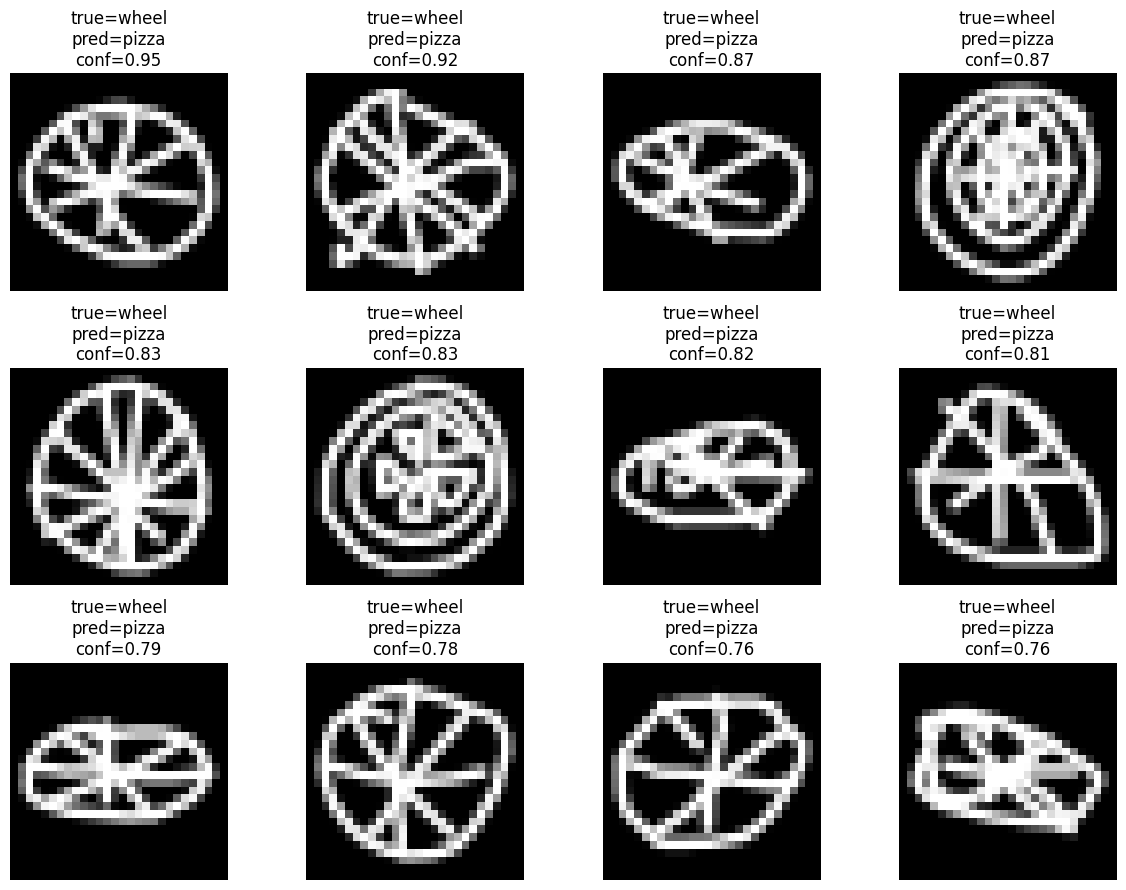

In [13]:
gelu3_results = run_champion_experiment(
    tag="ChampionMLP_GELU_3L",
    width=512,
    depth=3,
    act="gelu",
    dropout=0.10,
    use_batchnorm=True,
    max_lr=6e-3,
    weight_decay=1e-4,
    label_smoothing=0.02,
    epochs=EPOCHS,
    use_augmentation=True,
    run_live_diagnostics=True,
    top_k_grad_layers=10,
 )

## 4) ChampionMLP with GELU 4 layers (Variant A)


Running ChampionMLP_GELU_4L_A
Augmentation enabled: True
Trainable parameters: 965455
[ChampionMLP_GELU_4L_A] Epoch 01/40 | Train: loss 1.3653, acc 0.5717 | Val: loss 0.9966, acc 0.7033 | LR: 0.000792 | Best Val Acc: 0.7033 (ep 1)
[ChampionMLP_GELU_4L_A] Epoch 02/40 | Train: loss 1.0867, acc 0.6636 | Val: loss 0.9355, acc 0.7243 | LR: 0.001266 | Best Val Acc: 0.7243 (ep 2)
[ChampionMLP_GELU_4L_A] Epoch 03/40 | Train: loss 1.0358, acc 0.6812 | Val: loss 0.9004, acc 0.7344 | LR: 0.001976 | Best Val Acc: 0.7344 (ep 3)
[ChampionMLP_GELU_4L_A] Epoch 04/40 | Train: loss 0.9939, acc 0.6992 | Val: loss 0.8758, acc 0.7480 | LR: 0.002814 | Best Val Acc: 0.7480 (ep 4)
[ChampionMLP_GELU_4L_A] Epoch 05/40 | Train: loss 0.9533, acc 0.7155 | Val: loss 0.8626, acc 0.7437 | LR: 0.003651 | Best Val Acc: 0.7480 (ep 4)
[ChampionMLP_GELU_4L_A] Epoch 06/40 | Train: loss 0.9251, acc 0.7242 | Val: loss 0.8251, acc 0.7626 | LR: 0.004361 | Best Val Acc: 0.7626 (ep 6)
[ChampionMLP_GELU_4L_A] Epoch 07/40 | Train

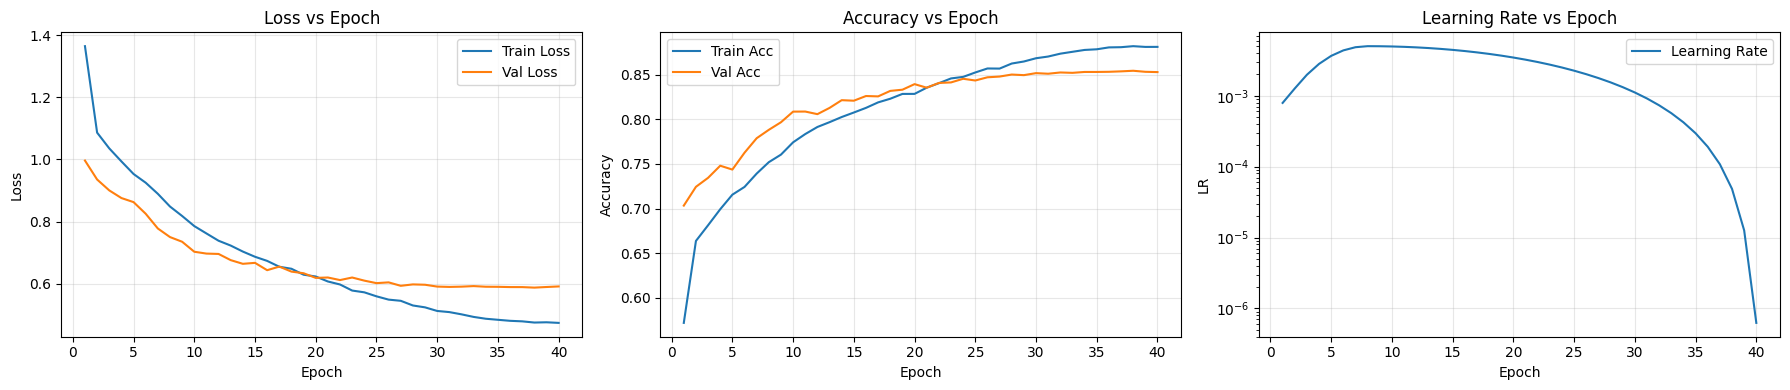

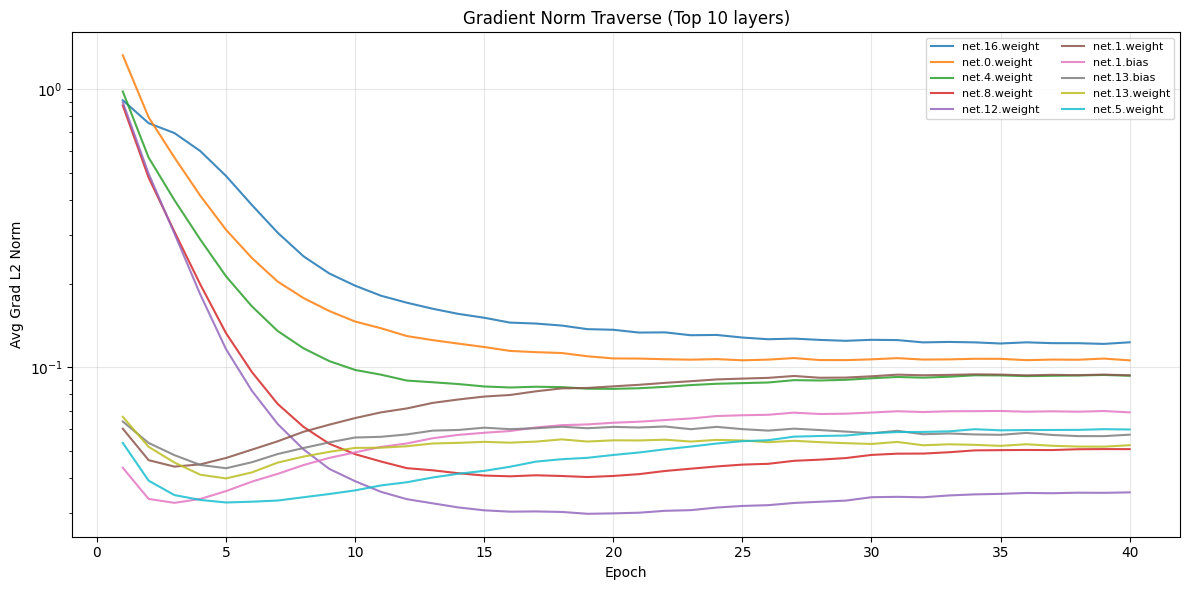

Validation accuracy: 0.8545


<Figure size 1200x1000 with 0 Axes>

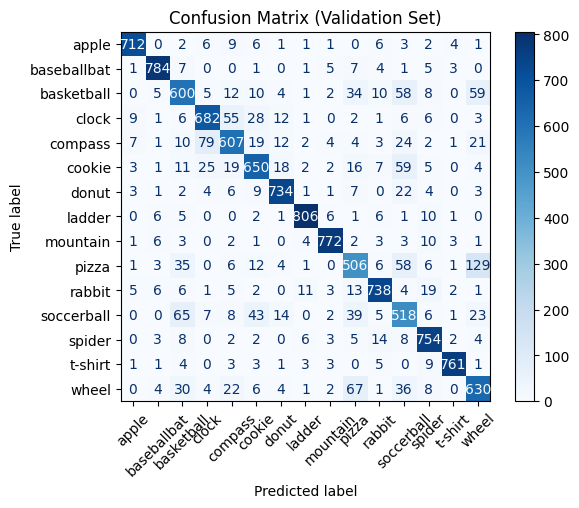


Classwise accuracy (low -> high):
pizza           accuracy: 0.659
soccerball      accuracy: 0.709
basketball      accuracy: 0.743
compass         accuracy: 0.763
wheel           accuracy: 0.773
cookie          accuracy: 0.791
clock           accuracy: 0.840
rabbit          accuracy: 0.904
donut           accuracy: 0.921
spider          accuracy: 0.930
apple           accuracy: 0.944
mountain        accuracy: 0.952
ladder          accuracy: 0.954
t-shirt         accuracy: 0.957
baseballbat     accuracy: 0.957
Top misclassified class pairs:
  pizza -> wheel: 129


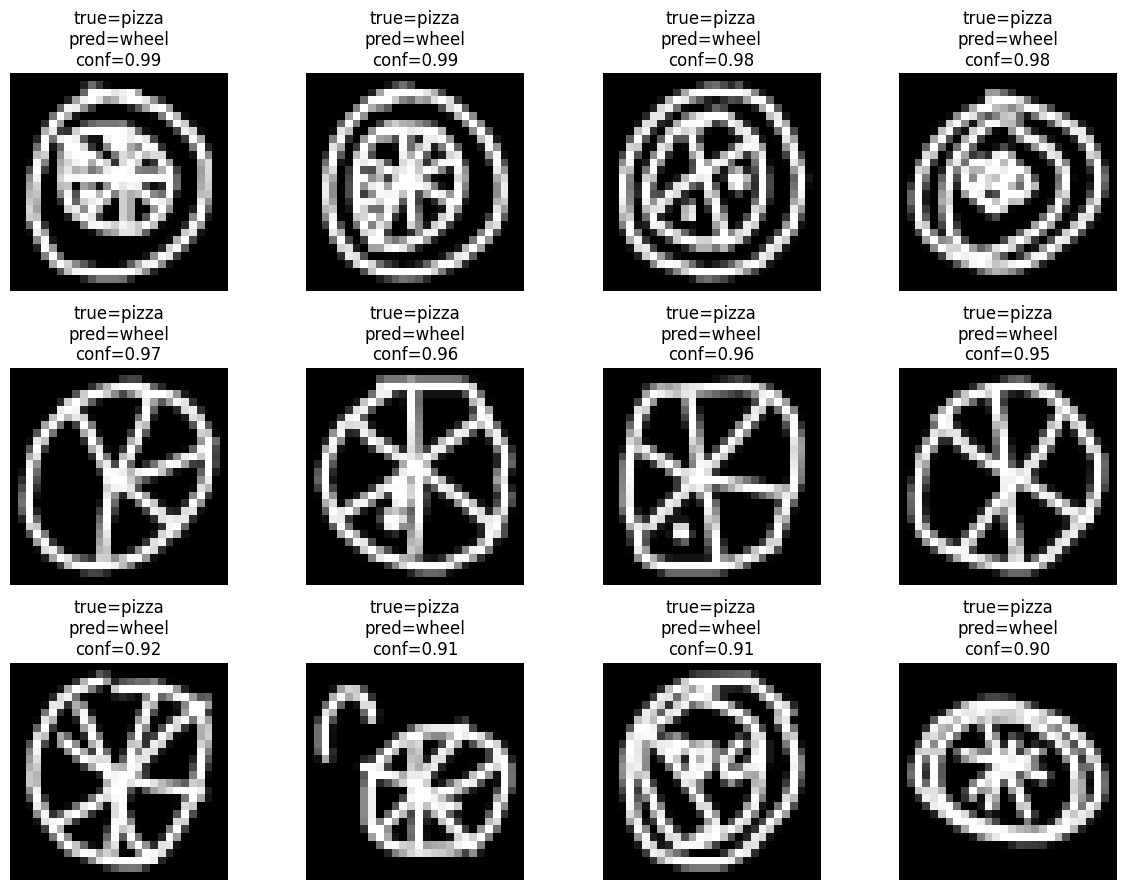

  compass -> clock: 79


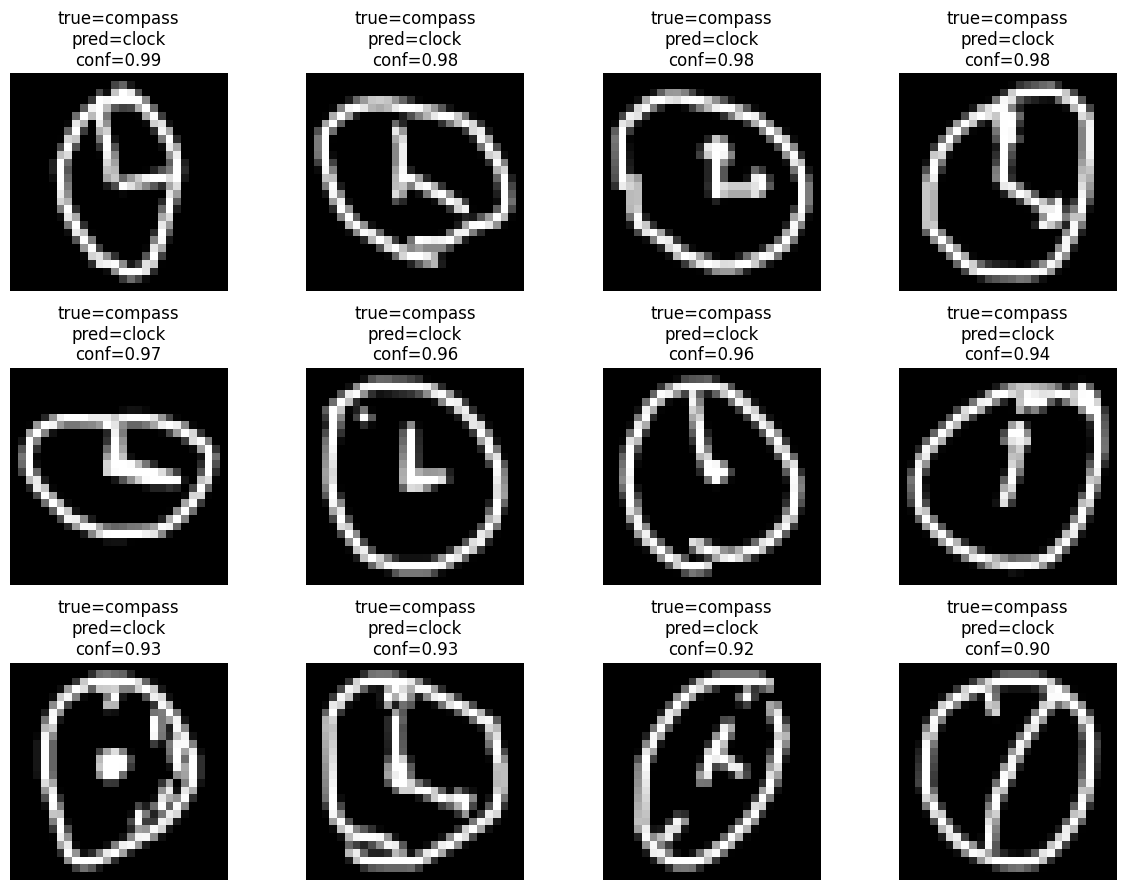

  wheel -> pizza: 67


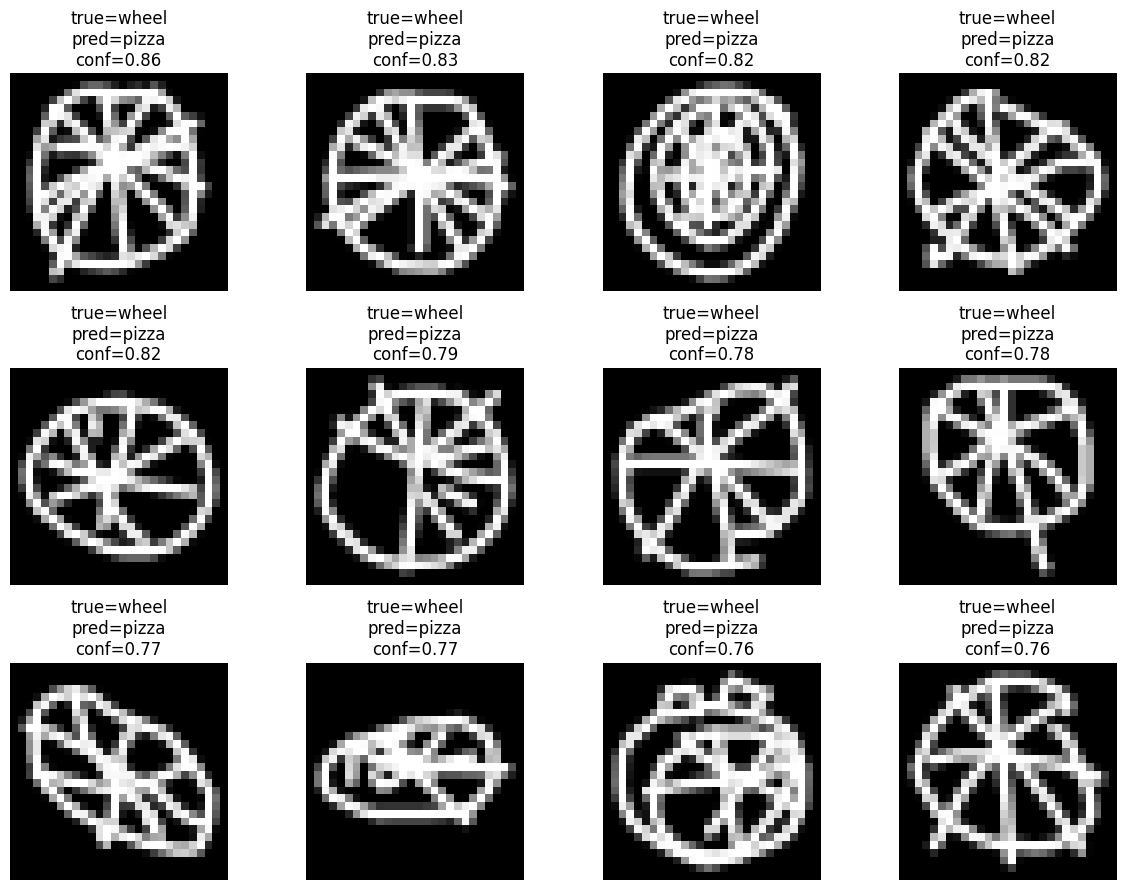

  soccerball -> basketball: 65


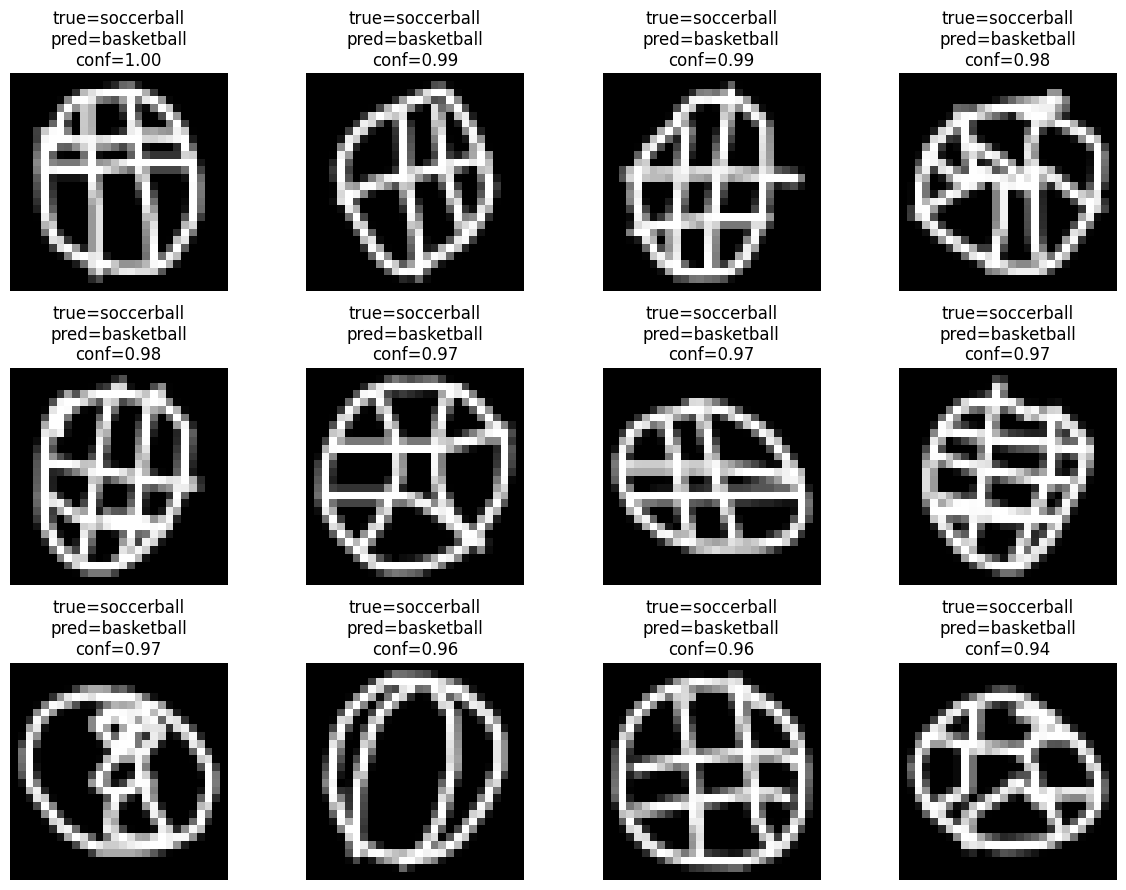

  basketball -> wheel: 59


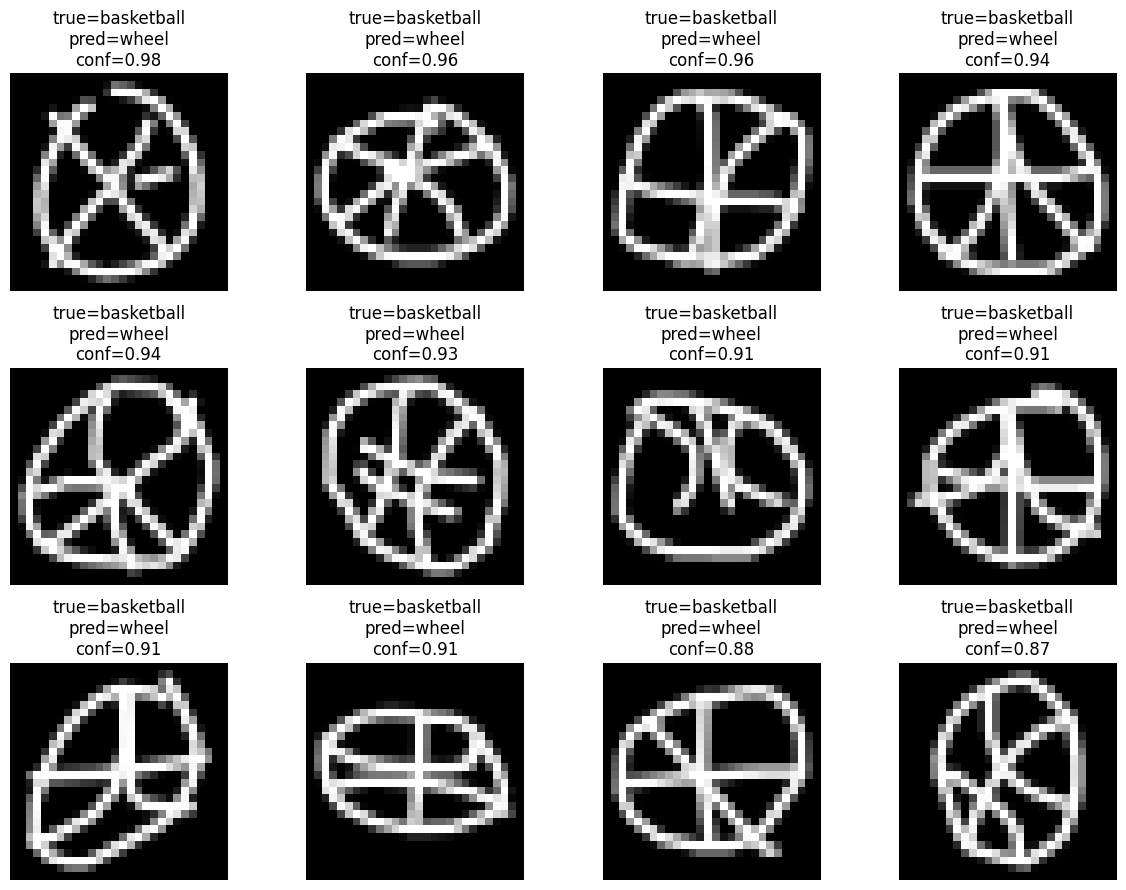

In [14]:
gelu4a_results = run_champion_experiment(
    tag="ChampionMLP_GELU_4L_A",
    width=448,
    depth=4,
    act="gelu",
    dropout=0.10,
    use_batchnorm=True,
    max_lr=5e-3,
    weight_decay=2e-4,
    label_smoothing=0.02,
    epochs=EPOCHS,
    use_augmentation=True,
    run_live_diagnostics=True,
    top_k_grad_layers=10,
 )

## 5) ChampionMLP with GELU 4 layers (Variant B)


Running ChampionMLP_GELU_4L_B
Augmentation enabled: True
Trainable parameters: 1201679
[ChampionMLP_GELU_4L_B] Epoch 01/40 | Train: loss 1.3614, acc 0.5850 | Val: loss 1.0078, acc 0.7097 | LR: 0.000633 | Best Val Acc: 0.7097 (ep 1)
[ChampionMLP_GELU_4L_B] Epoch 02/40 | Train: loss 1.0953, acc 0.6755 | Val: loss 0.9402, acc 0.7364 | LR: 0.001013 | Best Val Acc: 0.7364 (ep 2)
[ChampionMLP_GELU_4L_B] Epoch 03/40 | Train: loss 1.0385, acc 0.7002 | Val: loss 0.9352, acc 0.7373 | LR: 0.001581 | Best Val Acc: 0.7373 (ep 3)
[ChampionMLP_GELU_4L_B] Epoch 04/40 | Train: loss 1.0086, acc 0.7095 | Val: loss 0.9114, acc 0.7430 | LR: 0.002251 | Best Val Acc: 0.7430 (ep 4)
[ChampionMLP_GELU_4L_B] Epoch 05/40 | Train: loss 0.9741, acc 0.7230 | Val: loss 0.9005, acc 0.7550 | LR: 0.002921 | Best Val Acc: 0.7550 (ep 5)
[ChampionMLP_GELU_4L_B] Epoch 06/40 | Train: loss 0.9417, acc 0.7335 | Val: loss 0.8392, acc 0.7712 | LR: 0.003488 | Best Val Acc: 0.7712 (ep 6)
[ChampionMLP_GELU_4L_B] Epoch 07/40 | Trai

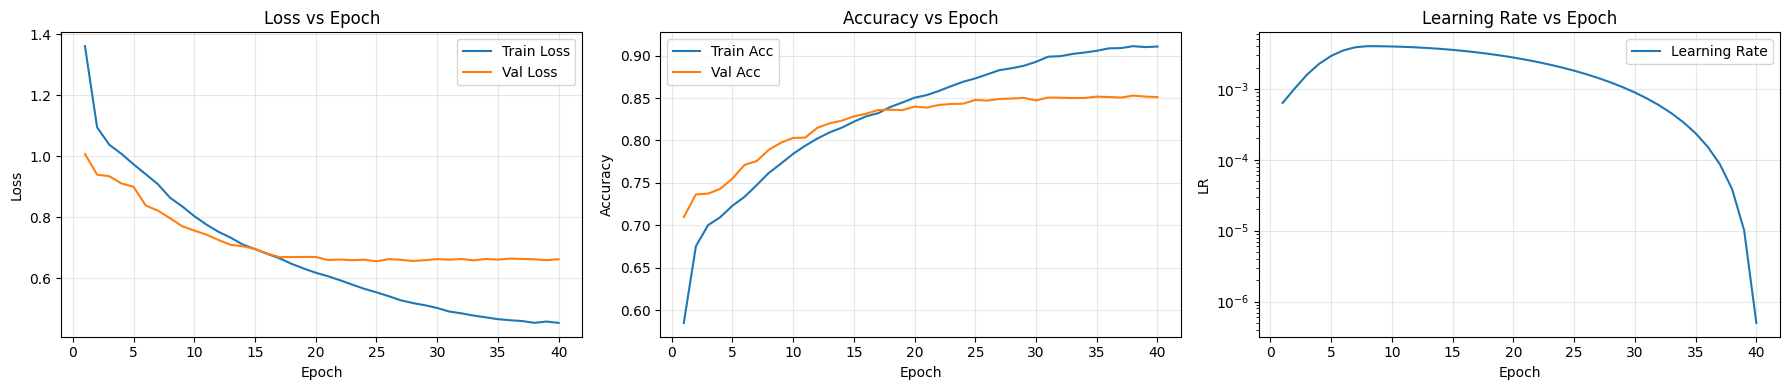

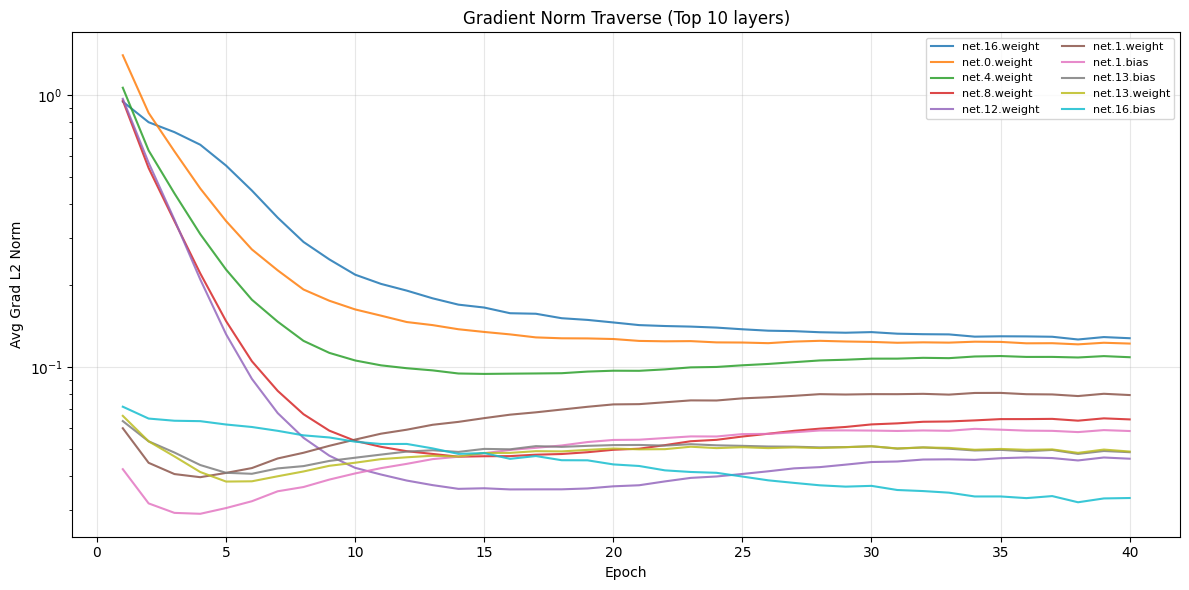

Validation accuracy: 0.8528


<Figure size 1200x1000 with 0 Axes>

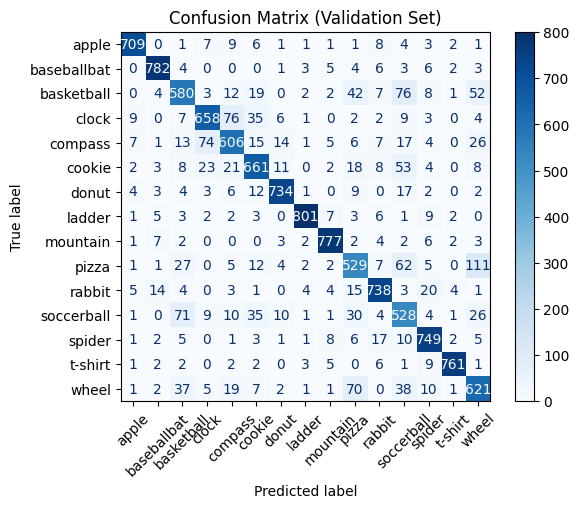


Classwise accuracy (low -> high):
pizza           accuracy: 0.689
basketball      accuracy: 0.718
soccerball      accuracy: 0.722
compass         accuracy: 0.761
wheel           accuracy: 0.762
cookie          accuracy: 0.804
clock           accuracy: 0.810
rabbit          accuracy: 0.904
donut           accuracy: 0.921
spider          accuracy: 0.924
apple           accuracy: 0.940
ladder          accuracy: 0.948
baseballbat     accuracy: 0.955
t-shirt         accuracy: 0.957
mountain        accuracy: 0.958
Top misclassified class pairs:
  pizza -> wheel: 111


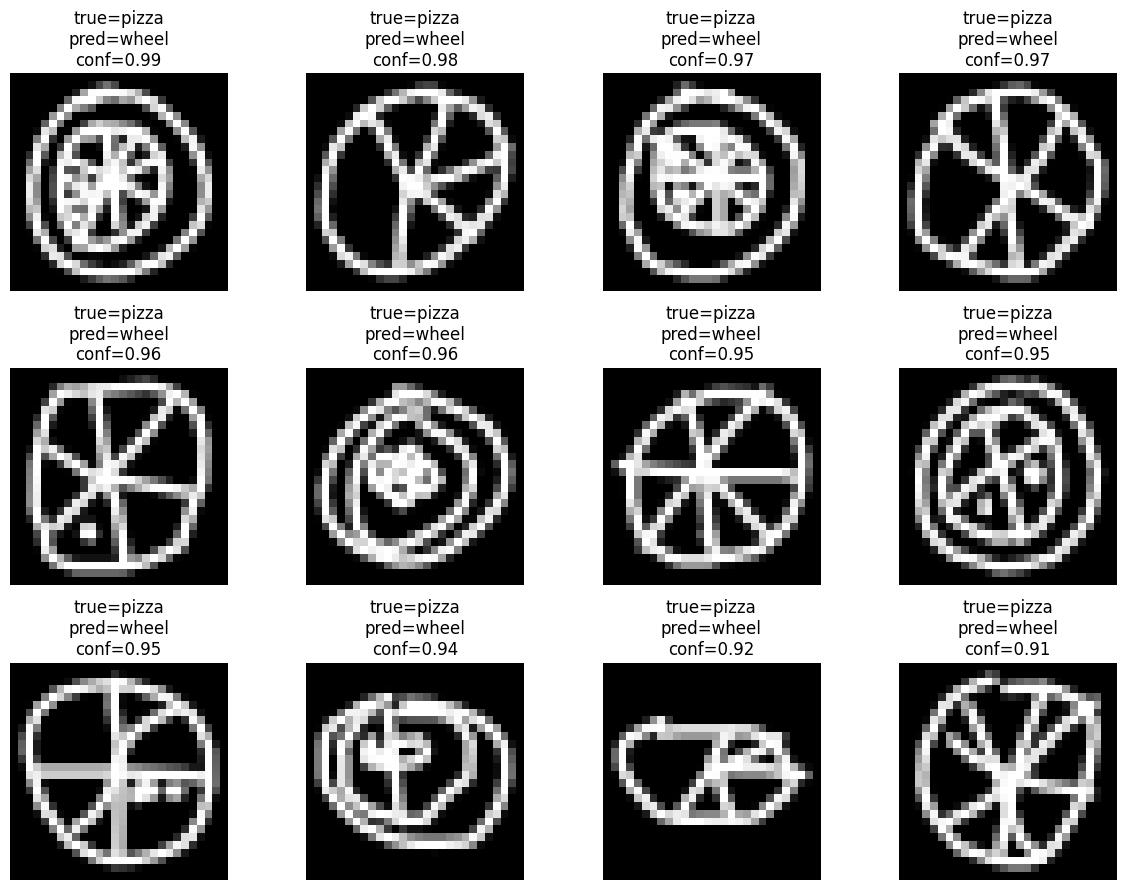

  basketball -> soccerball: 76


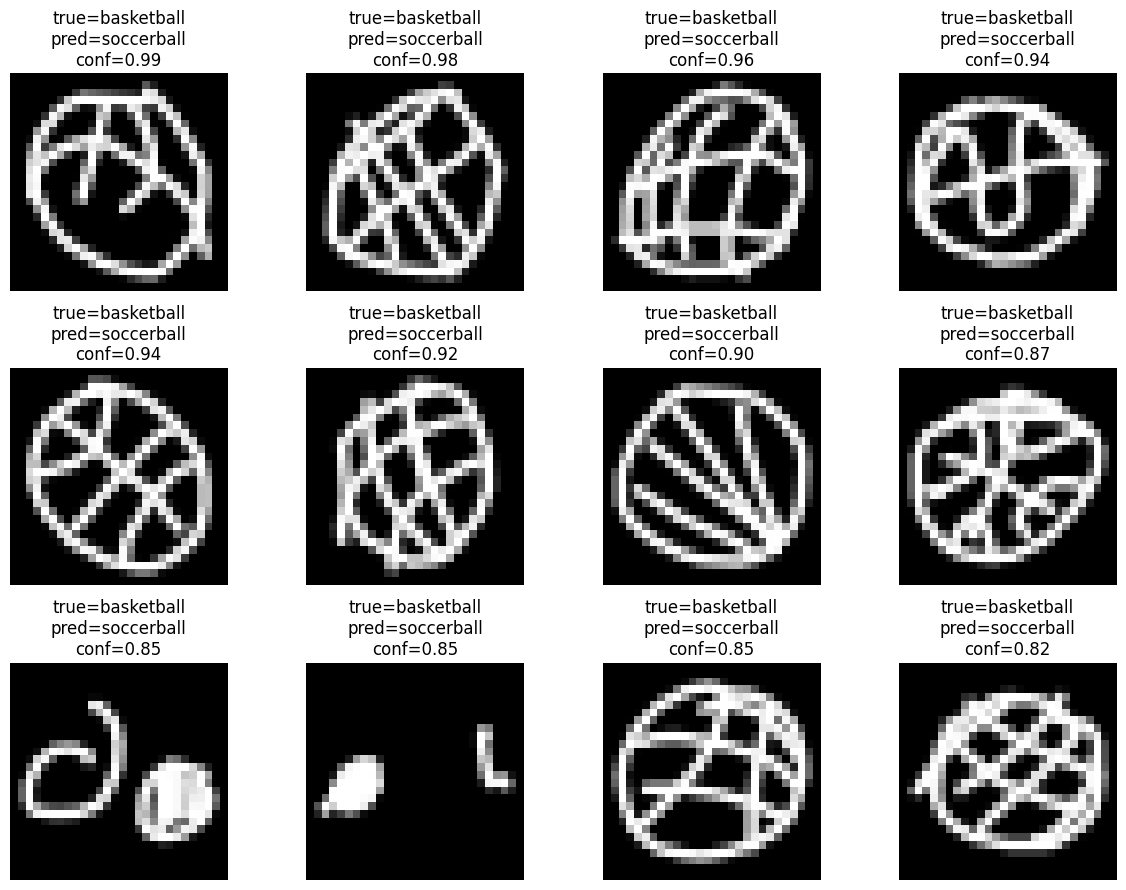

  clock -> compass: 76


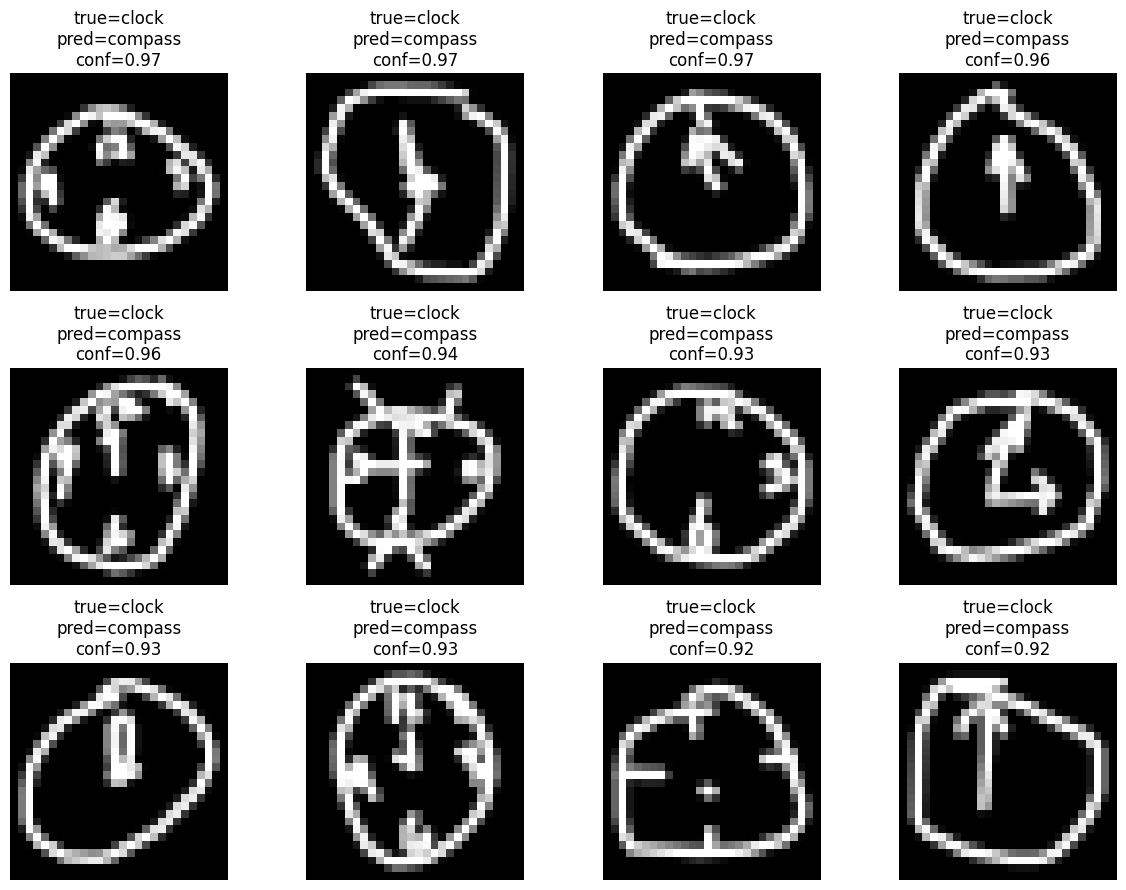

  compass -> clock: 74


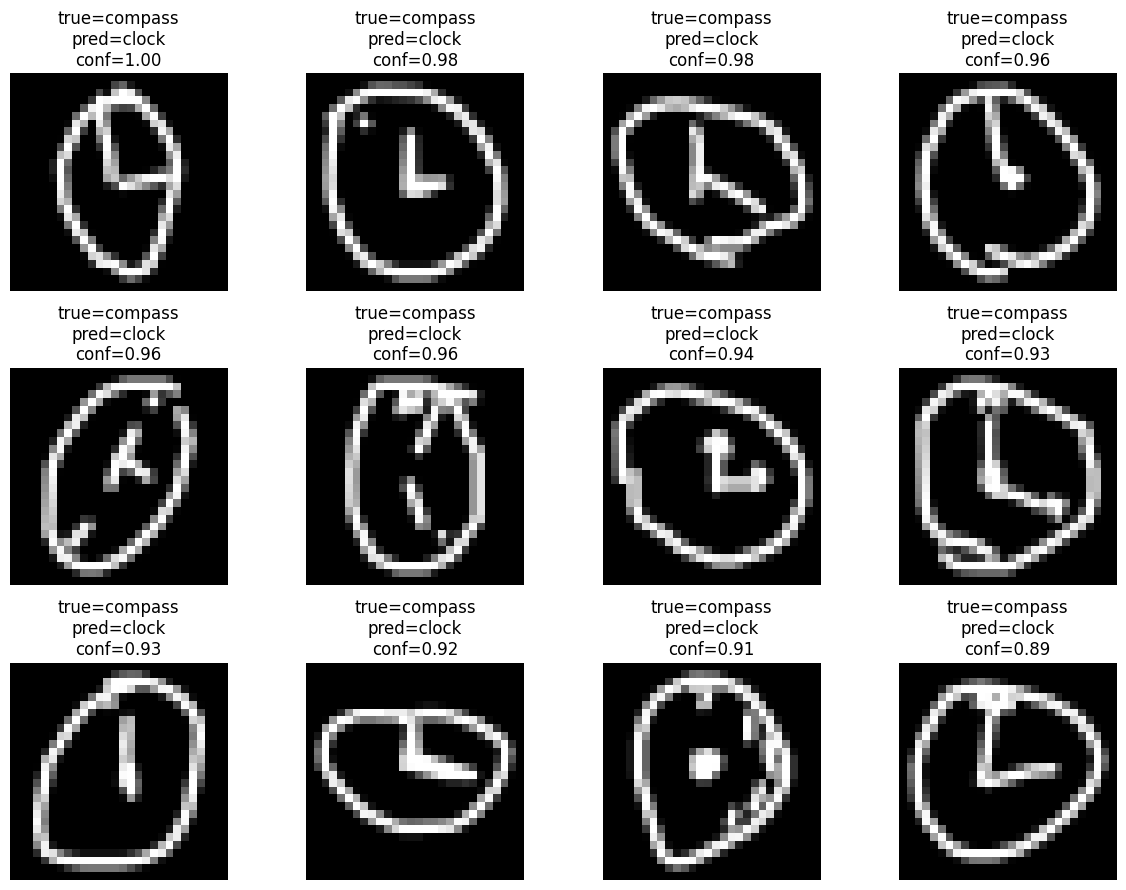

  soccerball -> basketball: 71


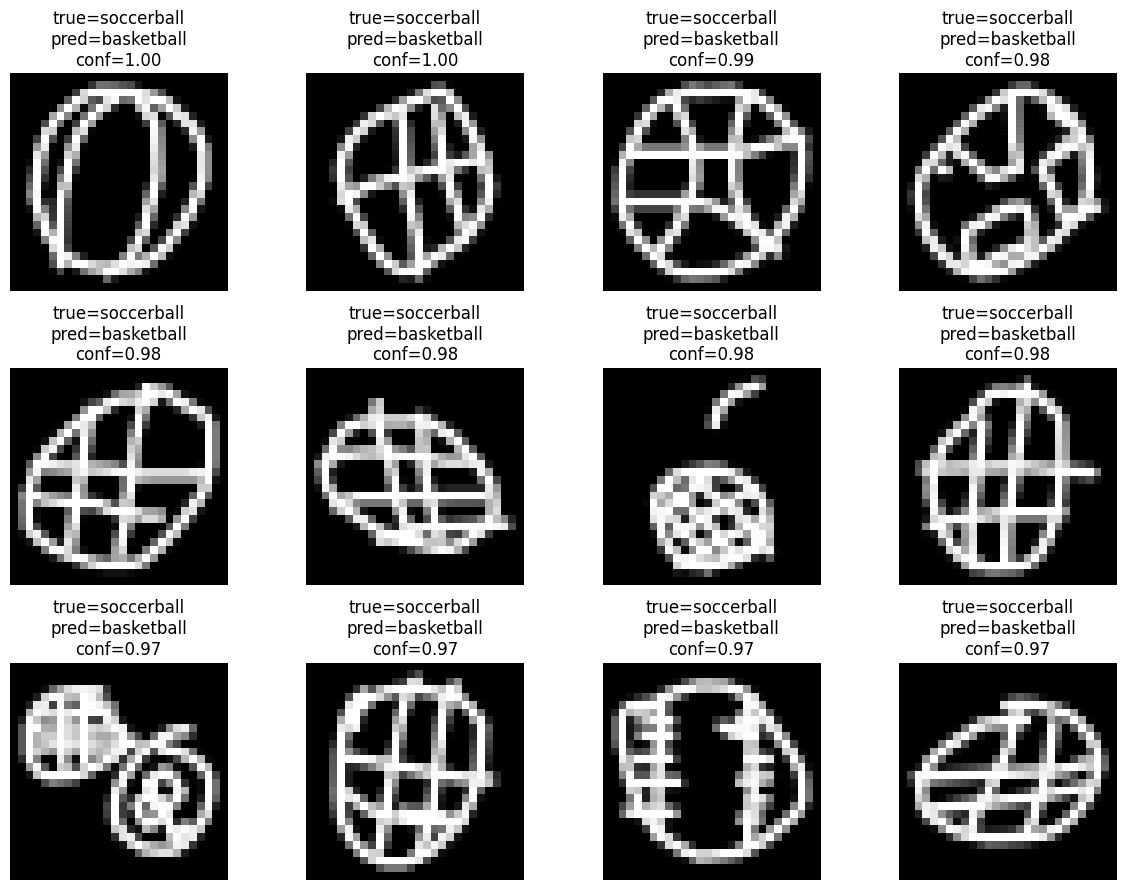

In [15]:
gelu4b_results = run_champion_experiment(
    tag="ChampionMLP_GELU_4L_B",
    width=512,
    depth=4,
    act="gelu",
    dropout=0.05,
    use_batchnorm=True,
    max_lr=4e-3,
    weight_decay=3e-4,
    label_smoothing=0.03,
    epochs=EPOCHS,
    use_augmentation=True,
    run_live_diagnostics=True,
    top_k_grad_layers=10,
 )

## Final Visualization and Analysis

Model comparison summary (Training vs Validation):
ChampionMLP_GELU_4L_A    | Params:   965,455 | Best Train/Val: 0.8821/0.8545 (best ep 38) | Final Train/Val: 0.8813/0.8530 | Generalization Gap: +0.0283 | Val Acc/MParam: 0.8851 | Final Val Loss: 0.5908 | Aug: Yes
ChampionMLP_GELU_3L      | Params:   937,999 | Best Train/Val: 0.8955/0.8538 (best ep 40) | Final Train/Val: 0.8955/0.8538 | Generalization Gap: +0.0417 | Val Acc/MParam: 0.9103 | Final Val Loss: 0.6044 | Aug: Yes
ChampionMLP_GELU_4L_B    | Params: 1,201,679 | Best Train/Val: 0.9111/0.8528 (best ep 38) | Final Train/Val: 0.9107/0.8511 | Generalization Gap: +0.0596 | Val Acc/MParam: 0.7097 | Final Val Loss: 0.6631 | Aug: Yes
ChampionMLP_GELU_2L      | Params:   674,319 | Best Train/Val: 0.8883/0.8508 (best ep 39) | Final Train/Val: 0.8882/0.8505 | Generalization Gap: +0.0377 | Val Acc/MParam: 1.2616 | Final Val Loss: 0.6180 | Aug: Yes
ChampionMLP_RELU_3L      | Params:   937,999 | Best Train/Val: 0.8686/0.8462 (best ep 37) | F

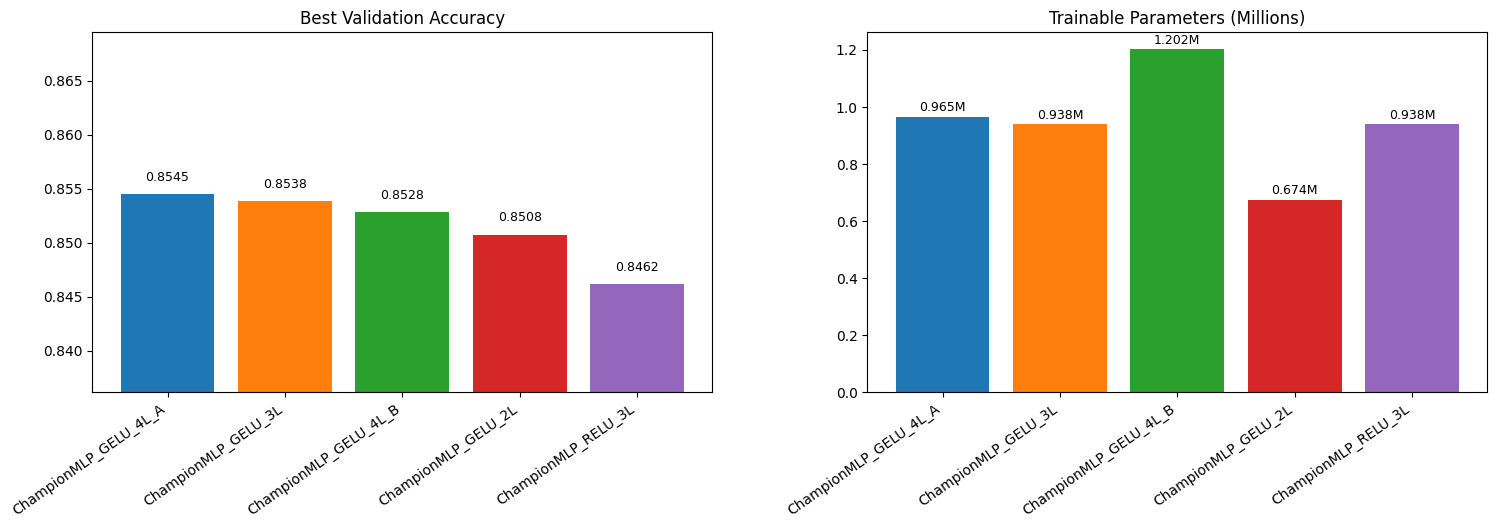


Total labeled samples used for class distribution: 60000


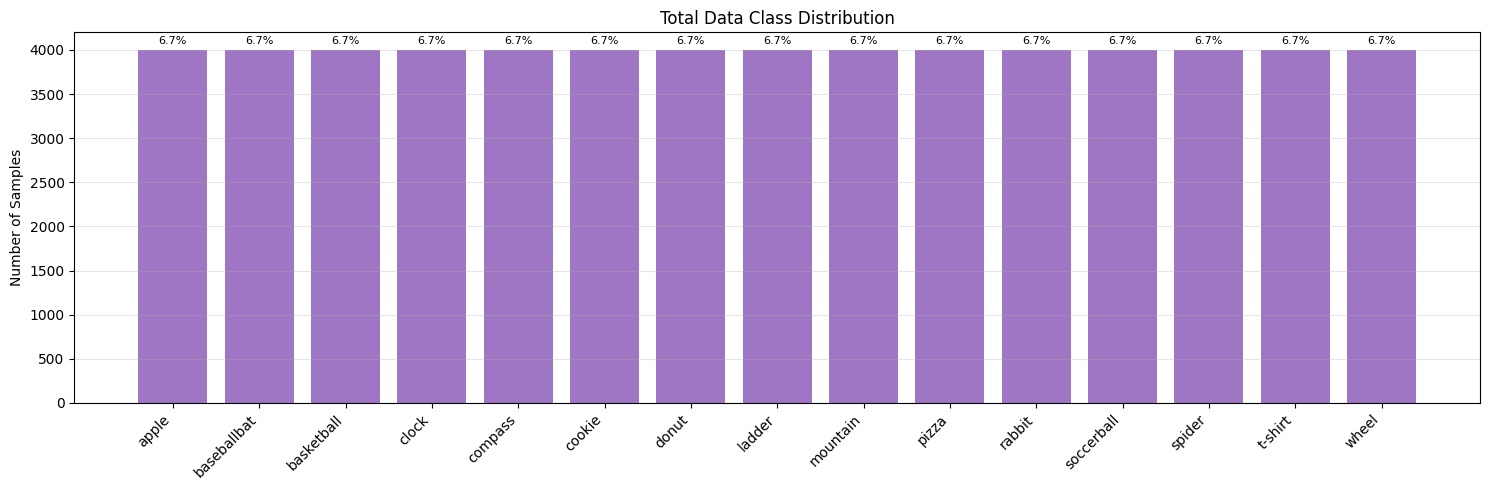

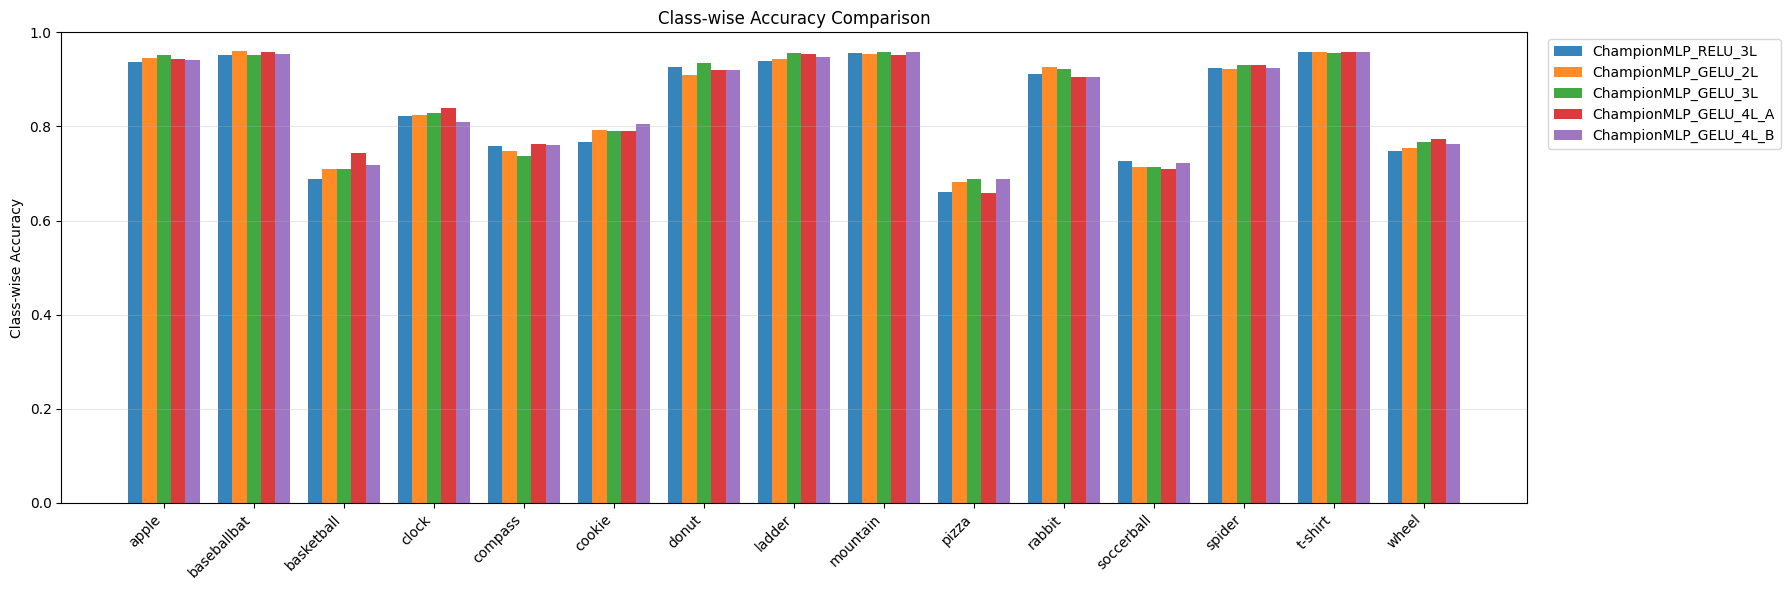


Class-wise accuracy delta vs ChampionMLP_RELU_3L:

ChampionMLP_GELU_2L - ChampionMLP_RELU_3L
donut           : -0.019
soccerball      : -0.014
compass         : -0.009
mountain        : -0.002
spider          : -0.002
t-shirt         : -0.001
clock           : +0.002
ladder          : +0.005
wheel           : +0.006
baseballbat     : +0.007
apple           : +0.009
rabbit          : +0.015
pizza           : +0.022
basketball      : +0.022
cookie          : +0.026

ChampionMLP_GELU_3L - ChampionMLP_RELU_3L
compass         : -0.021
soccerball      : -0.012
t-shirt         : -0.003
baseballbat     : -0.001
mountain        : +0.001
spider          : +0.005
clock           : +0.006
donut           : +0.008
rabbit          : +0.010
apple           : +0.015
ladder          : +0.015
wheel           : +0.020
basketball      : +0.021
cookie          : +0.023
pizza           : +0.027

ChampionMLP_GELU_4L_A - ChampionMLP_RELU_3L
soccerball      : -0.018
rabbit          : -0.007
donut           : 

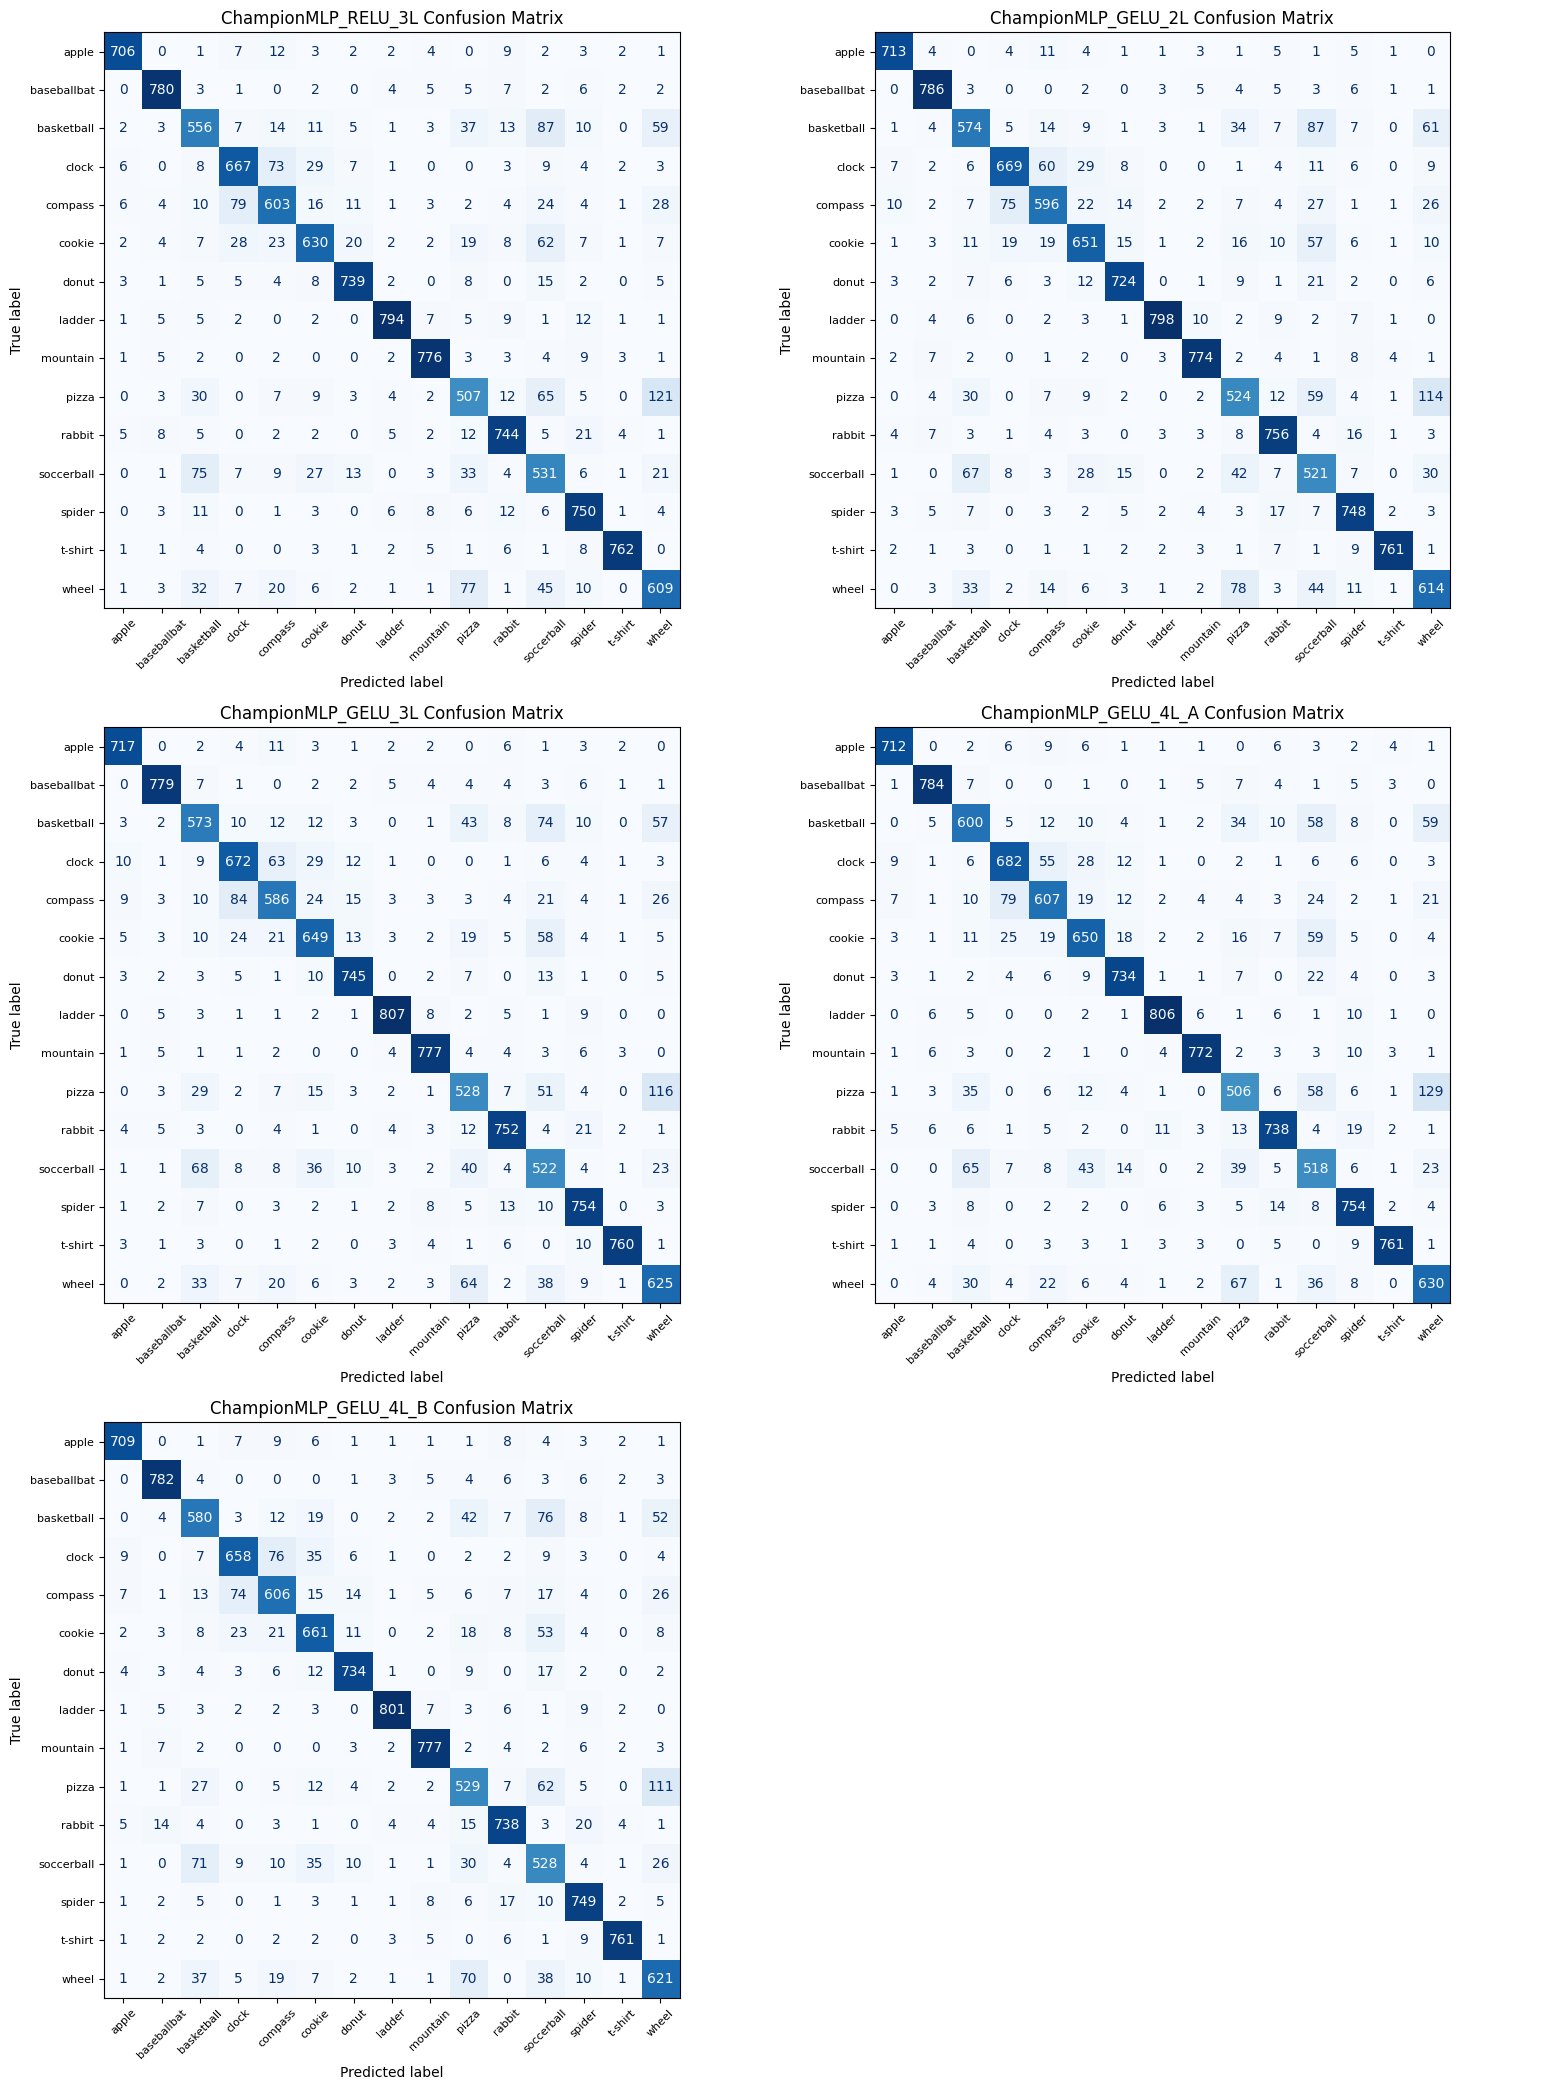


Comparison table (all models):


,Model,Activation,Hidden Layers,Augmentation,Params,Params (M),Best Epoch,Best Train Acc,Best Val Acc,Final Train Acc,Final Val Acc,Generalization Gap,Final Val Loss,Val Acc / MParam,Weight Decay,Scheduler,Best Model File
0,ChampionMLP_GELU_4L_A,GELU,4,Yes,965455,0.9655,38,0.8821,0.8545,0.8813,0.8530,0.0283,0.5908,0.8851,0.0002,OneCycleLR,./checkpoints/best_championmlp_gelu_4l_a.pth
1,ChampionMLP_GELU_3L,GELU,3,Yes,937999,0.9380,40,0.8955,0.8538,0.8955,0.8538,0.0417,0.6044,0.9103,0.0001,OneCycleLR,./checkpoints/best_championmlp_gelu_3l.pth
2,ChampionMLP_GELU_4L_B,GELU,4,Yes,1201679,1.2017,38,0.9111,0.8528,0.9107,0.8511,0.0596,0.6631,0.7097,0.0003,OneCycleLR,./checkpoints/best_championmlp_gelu_4l_b.pth
3,ChampionMLP_GELU_2L,GELU,2,Yes,674319,0.6743,39,0.8883,0.8508,0.8882,0.8505,0.0377,0.6180,1.2616,0.0001,OneCycleLR,./checkpoints/best_championmlp_gelu_2l.pth
4,ChampionMLP_RELU_3L,RELU,3,Yes,937999,0.9380,37,0.8686,0.8462,0.8686,0.8457,0.0230,0.6014,0.9021,0.0001,OneCycleLR,./checkpoints/best_championmlp_relu_3l.pth



Analysis summary:
- Best overall variant = ChampionMLP_GELU_4L_A (0.8545).
- Best 4-layer variant = ChampionMLP_GELU_4L_A (0.8545).
- Best parameter-efficiency = ChampionMLP_GELU_2L (1.2616 val acc / M param).
- Augmentation applied to all variants = True.
- Use the Generalization Gap column to discuss overfitting in the report.


## Final Comparison Analysis (Auto-generated)
- **Best overall validation accuracy:** ChampionMLP_GELU_4L_A (0.8545)
- **Best 4-layer variant:** ChampionMLP_GELU_4L_A (0.8545)
- **Best parameter-efficiency:** ChampionMLP_GELU_2L (1.2616 val acc / M param)
- **Augmentation applied to all variants:** True
- **Generalization:** all models show a train-vs-validation gap; use the `Generalization Gap` column in your report discussion.


In [16]:
# ==========================================
# MODEL COMPARISON + ANALYSIS
# ==========================================

import re
import pandas as pd
from IPython.display import display, Markdown

required_results = {
    "ChampionMLP_RELU_3L": "relu3_results",
    "ChampionMLP_GELU_2L": "gelu2_results",
    "ChampionMLP_GELU_3L": "gelu3_results",
    "ChampionMLP_GELU_4L_A": "gelu4a_results",
    "ChampionMLP_GELU_4L_B": "gelu4b_results",
}

model_results = {}
for model_name, result_name in required_results.items():
    if result_name not in globals():
        raise RuntimeError(f"Run {model_name} cell first.")
    model_results[model_name] = globals()[result_name]

for model_name, results in model_results.items():
    required_keys = {"history", "cm", "class_acc", "params"}
    missing = required_keys - set(results.keys())
    if missing:
        raise RuntimeError(f"Result keys missing for {model_name}: {missing}. Re-run its model cell.")

comparison = []
default_weight_decay = {
    "ChampionMLP_RELU_3L": 1e-4,
    "ChampionMLP_GELU_2L": 1e-4,
    "ChampionMLP_GELU_3L": 1e-4,
    "ChampionMLP_GELU_4L_A": 2e-4,
    "ChampionMLP_GELU_4L_B": 3e-4,
}
for model_name, results in model_results.items():
    history = results["history"]
    layer_match = re.search(r"_(\d+)L", model_name)
    fallback_layers = int(layer_match.group(1)) if layer_match else 0
    fallback_activation = "RELU" if "_RELU_" in model_name else "GELU"
    best_train_acc = float(np.max(history["train_acc"]))
    best_val_acc = float(history.get("best_val_acc", np.max(history["val_acc"])))
    params_m = results["params"] / 1_000_000

    comparison.append(
        {
            "Model": model_name,
            "Activation": results.get("activation", fallback_activation),
            "Hidden Layers": int(results.get("hidden_layers", fallback_layers)),
            "Params": int(results["params"]),
            "Best Train Acc": best_train_acc,
            "Best Val Acc": best_val_acc,
            "Best Epoch": int(history.get("best_epoch", int(np.argmax(history["val_acc"]) + 1))),
            "Final Train Acc": float(history["train_acc"][-1]),
            "Final Val Acc": float(history["val_acc"][-1]),
            "Final Val Loss": float(history["val_loss"][-1]),
            "Generalization Gap": float(history["train_acc"][-1] - history["val_acc"][-1]),
            "Val Acc / MParam": best_val_acc / params_m,
            "Weight Decay": float(results.get("weight_decay", default_weight_decay.get(model_name, np.nan))),
            "Scheduler": results.get("scheduler", "OneCycleLR"),
            "Augmentation": "Yes" if results.get("use_augmentation", False) else "No",
            "Best Model File": results.get("checkpoint", ""),
        }
    )

comparison_sorted = sorted(comparison, key=lambda row: row["Best Val Acc"], reverse=True)

print("Model comparison summary (Training vs Validation):")
for row in comparison_sorted:
    print(
        f"{row['Model']:24s} | "
        f"Params: {row['Params']:>9,} | "
        f"Best Train/Val: {row['Best Train Acc']:.4f}/{row['Best Val Acc']:.4f} (best ep {row['Best Epoch']}) | "
        f"Final Train/Val: {row['Final Train Acc']:.4f}/{row['Final Val Acc']:.4f} | "
        f"Generalization Gap: {row['Generalization Gap']:+.4f} | "
        f"Val Acc/MParam: {row['Val Acc / MParam']:.4f} | "
        f"Final Val Loss: {row['Final Val Loss']:.4f} | "
        f"Aug: {row['Augmentation']}"
    )

if len(comparison_sorted) >= 2:
    winner = comparison_sorted[0]["Model"]
    runner_up = comparison_sorted[1]["Model"]
    margin = comparison_sorted[0]["Best Val Acc"] - comparison_sorted[1]["Best Val Acc"]
    print(f"\nWinner by best validation accuracy: {winner} over {runner_up} (margin = {margin:.4f})")

models = [row["Model"] for row in comparison_sorted]
best_val_acc = [row["Best Val Acc"] for row in comparison_sorted]
params_millions = [row["Params"] / 1_000_000 for row in comparison_sorted]
plot_colors = [plt.cm.tab10(i) for i in range(len(comparison_sorted))]
positions = np.arange(len(models))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(positions, best_val_acc, color=plot_colors)
axes[0].set_title("Best Validation Accuracy")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(models, rotation=35, ha="right")
axes[0].set_ylim(min(best_val_acc) - 0.01, max(best_val_acc) + 0.015)
for index, value in enumerate(best_val_acc):
    axes[0].text(index, value + 0.001, f"{value:.4f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(positions, params_millions, color=plot_colors)
axes[1].set_title("Trainable Parameters (Millions)")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(models, rotation=35, ha="right")
for index, value in enumerate(params_millions):
    axes[1].text(index, value + 0.01, f"{value:.3f}M", ha="center", va="bottom", fontsize=9)

fig.subplots_adjust(bottom=0.28, wspace=0.25)
plt.show()

# ------------------------------
# Class distribution (total data)
# ------------------------------
if not hasattr(full_train_dataset, "y") or full_train_dataset.y is None:
    raise RuntimeError("full_train_dataset does not contain labels needed for total class distribution.")

total_labels = full_train_dataset.y.cpu().numpy() if torch.is_tensor(full_train_dataset.y) else np.asarray(full_train_dataset.y)
class_counts = np.bincount(total_labels.astype(int), minlength=len(CLASSES))
class_percent = 100.0 * class_counts / class_counts.sum()

print(f"\nTotal labeled samples used for class distribution: {class_counts.sum()}")

x = np.arange(len(CLASSES))
plt.figure(figsize=(15, 5))
plt.bar(x, class_counts, color="tab:purple", alpha=0.9)
plt.xticks(x, CLASSES, rotation=45, ha="right")
plt.ylabel("Number of Samples")
plt.title("Total Data Class Distribution")
plt.grid(axis="y", alpha=0.3)

for idx, (count, pct) in enumerate(zip(class_counts, class_percent)):
    plt.text(idx, count + max(class_counts) * 0.01, f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------
# Class-wise accuracy comparison
# ------------------------------
class_acc_dict = {
    name: np.asarray(results["class_acc"])
    for name, results in model_results.items()
}

x = np.arange(len(CLASSES))
num_models = len(class_acc_dict)
bar_width = 0.8 / num_models
offset_start = -0.4 + bar_width / 2

plt.figure(figsize=(18, 6))
for model_index, (name, acc_values) in enumerate(class_acc_dict.items()):
    positions = x + offset_start + model_index * bar_width
    plt.bar(positions, acc_values, width=bar_width, label=name, alpha=0.9, color=plot_colors[model_index])

plt.xticks(x, CLASSES, rotation=45, ha="right")
plt.ylabel("Class-wise Accuracy")
plt.title("Class-wise Accuracy Comparison")
plt.ylim(0.0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

reference_model = "ChampionMLP_RELU_3L"
print(f"\nClass-wise accuracy delta vs {reference_model}:")
reference_class_acc = class_acc_dict[reference_model]
for model_name in [name for name in class_acc_dict.keys() if name != reference_model]:
    class_delta = class_acc_dict[model_name] - reference_class_acc
    print(f"\n{model_name} - {reference_model}")
    for class_index in np.argsort(class_delta):
        print(f"{CLASSES[class_index]:15s} : {class_delta[class_index]:+0.3f}")

# ------------------------------
# Confusion matrix comparison (2 per row)
# ------------------------------
num_models = len(model_results)
ncols = 2
nrows = int(np.ceil(num_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 7 * nrows))
axes = np.array(axes).reshape(-1)

for axis, (name, results) in zip(axes, model_results.items()):
    cm = np.asarray(results["cm"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=axis, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)
    axis.set_title(f"{name} Confusion Matrix", fontsize=12)
    axis.tick_params(axis="x", labelsize=8)
    axis.tick_params(axis="y", labelsize=8)

for axis in axes[num_models:]:
    axis.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------
# Comparison table (all models)
# ------------------------------
comparison_table = pd.DataFrame(comparison_sorted).copy()
comparison_table["Params (M)"] = comparison_table["Params"] / 1_000_000
comparison_table = comparison_table[[
    "Model",
    "Activation",
    "Hidden Layers",
    "Augmentation",
    "Params",
    "Params (M)",
    "Best Epoch",
    "Best Train Acc",
    "Best Val Acc",
    "Final Train Acc",
    "Final Val Acc",
    "Generalization Gap",
    "Final Val Loss",
    "Val Acc / MParam",
    "Weight Decay",
    "Scheduler",
    "Best Model File",
]]

print("\nComparison table (all models):")
display(comparison_table.round(4))

# ------------------------------
# Analysis summary (for report)
# ------------------------------
best_overall = comparison_sorted[0]
best_4layer = max(
    [row for row in comparison_sorted if int(row["Hidden Layers"]) == 4],
    key=lambda row: row["Best Val Acc"],
)
best_eff_model = max(comparison_sorted, key=lambda row: row["Val Acc / MParam"])
all_aug = all(row["Augmentation"] == "Yes" for row in comparison_sorted)

print("\nAnalysis summary:")
print(f"- Best overall variant = {best_overall['Model']} ({best_overall['Best Val Acc']:.4f}).")
print(f"- Best 4-layer variant = {best_4layer['Model']} ({best_4layer['Best Val Acc']:.4f}).")
print(
    f"- Best parameter-efficiency = {best_eff_model['Model']} "
    f"({best_eff_model['Val Acc / MParam']:.4f} val acc / M param)."
)
print(f"- Augmentation applied to all variants = {all_aug}.")
print("- Use the Generalization Gap column to discuss overfitting in the report.")

analysis_md = f"""## Final Comparison Analysis (Auto-generated)
- **Best overall validation accuracy:** {best_overall['Model']} ({best_overall['Best Val Acc']:.4f})
- **Best 4-layer variant:** {best_4layer['Model']} ({best_4layer['Best Val Acc']:.4f})
- **Best parameter-efficiency:** {best_eff_model['Model']} ({best_eff_model['Val Acc / MParam']:.4f} val acc / M param)
- **Augmentation applied to all variants:** {all_aug}
- **Generalization:** all models show a train-vs-validation gap; use the `Generalization Gap` column in your report discussion.
"""
display(Markdown(analysis_md))

In [17]:
# ==========================================
# TEST INFERENCE + SUBMISSION EXPORT (ALL MODELS)
# ==========================================

from torch.utils.data import DataLoader
import re

result_candidates = {
    "ChampionMLP_RELU_3L": globals().get("relu3_results"),
    "ChampionMLP_GELU_2L": globals().get("gelu2_results"),
    "ChampionMLP_GELU_3L": globals().get("gelu3_results"),
    "ChampionMLP_GELU_4L_A": globals().get("gelu4a_results"),
    "ChampionMLP_GELU_4L_B": globals().get("gelu4b_results"),
}

available_results = {
    name: result
    for name, result in result_candidates.items()
    if isinstance(result, dict) and "model" in result and "history" in result
}

if not available_results:
    raise RuntimeError("No trained model results found. Run variant training cells first.")

results_dir = globals().get("RESULTS_DIR", "./results")
os.makedirs(results_dir, exist_ok=True)

def sanitize_model_name(model_name):
    return re.sub(r"[^0-9A-Za-z_]+", "_", model_name)

def run_test_inference(model, test_loader):
    model.eval()
    all_test_preds = []
    with torch.no_grad():
        for batch in test_loader:
            images = batch[0] if isinstance(batch, (tuple, list)) else batch
            images = normalize_batch(images).to(DEVICE)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            all_test_preds.append(preds.cpu().numpy())
    return np.concatenate(all_test_preds).astype(int)

test_dataset = QuickDrawDataset(TEST_FILE, mode="test")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

exported_files = {}
for model_name, result in available_results.items():
    model = result["model"]

    checkpoint_path = result.get("checkpoint", "")
    if checkpoint_path and os.path.exists(checkpoint_path):
        state_dict = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(state_dict)
        print(f"[{model_name}] Loaded checkpoint: {checkpoint_path}")
    else:
        print(f"[{model_name}] Checkpoint not found; using in-memory model weights.")

    test_preds = run_test_inference(model, test_loader)

    safe_name = sanitize_model_name(model_name)
    output_file = os.path.join(results_dir, f"submission_{safe_name}.txt")
    with open(output_file, "w") as f:
        f.write(",".join(map(str, test_preds.tolist())))

    exported_files[model_name] = output_file
    print(f"[{model_name}] Exported {len(test_preds)} predictions -> {output_file}")

if "comparison_sorted" in globals() and comparison_sorted:
    best_model_name = comparison_sorted[0]["Model"]
    best_output_file = exported_files.get(best_model_name)
    if best_output_file and os.path.exists(best_output_file):
        final_submission_file = os.path.join(results_dir, "submission.txt")
        with open(best_output_file, "r") as src, open(final_submission_file, "w") as dst:
            dst.write(src.read())
        print(f"\nUpdated {final_submission_file} from best model: {best_model_name}")

print("\nAll exported files:")
for model_name, file_name in exported_files.items():
    print(f"- {model_name}: {file_name}")



Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
[ChampionMLP_RELU_3L] Loaded checkpoint: ./checkpoints/best_championmlp_relu_3l.pth
[ChampionMLP_RELU_3L] Exported 15000 predictions -> ./results/submission_ChampionMLP_RELU_3L.txt
[ChampionMLP_GELU_2L] Loaded checkpoint: ./checkpoints/best_championmlp_gelu_2l.pth
[ChampionMLP_GELU_2L] Exported 15000 predictions -> ./results/submission_ChampionMLP_GELU_2L.txt
[ChampionMLP_GELU_3L] Loaded checkpoint: ./checkpoints/best_championmlp_gelu_3l.pth
[ChampionMLP_GELU_3L] Exported 15000 predictions -> ./results/submission_ChampionMLP_GELU_3L.txt
[ChampionMLP_GELU_4L_A] Loaded checkpoint: ./checkpoints/best_championmlp_gelu_4l_a.pth
[ChampionMLP_GELU_4L_A] Exported 15000 predictions -> ./results/submission_ChampionMLP_GELU_4L_A.txt
[ChampionMLP_GELU_4L_B] Loaded checkpoint: ./checkpoints/best_championmlp_gelu_4l_b.pth
[ChampionMLP_GELU_4L_B] Exported 15000 predictions -> ./results/submission_ChampionMLP_GELU_